# 05 — t-SNE of Pruned Models in Metric Spaces

Each **point** represents one model variant (calibration source × pruning level).
There are 13 points per plot: 3 calibration schemas × 4 pruning levels (20/40/60/80%) + 1 shared baseline.

The feature vector for each model is the **N-dimensional vector of per-example metric values**
computed over a given eval benchmark (N=1319 for GSM8K, N=33 for HumanEval+, N=1171 for ARC-Challenge).
The baseline has an all-zero feature vector (metric of a distribution vs. itself = 0).

**Layout**: 4 figures (one per metric: KLD, JSD, EMD, Chamfer), each with 3 panels (one per eval benchmark).

**Goal**: do models cluster by pruning level (how much was pruned) or by calibration source (what was
used to determine what to prune)?  If pruning level dominates, points should form concentric shells
around the baseline.  If calibration source dominates, the three cal groups should be spatially separate.

In [2]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "pyproject.toml").is_file():
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env", override=False)
except ImportError:
    pass

print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /var/home/three-kingdoms/work/pruning-metrics


In [3]:
import json
import re
import concurrent.futures
import boto3

AWS_PROFILE    = os.environ.get("AWS_PROFILE", "rengz")
RESULTS_BUCKET = os.environ.get("RESULTS_BUCKET", "pruning-metrics-results-414266451290")

NOTEBOOK_DIR = Path.cwd()
RESULTS_DIR  = NOTEBOOK_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

experiment_config_path = NOTEBOOK_DIR / "experiment_config.json"
_cfg = json.loads(experiment_config_path.read_text(encoding="utf-8"))

TF_URIS = _cfg["teacher_forced_uris"]

PRUNING_LEVELS  = [0, 20, 40, 60, 80]
NONZERO_LEVELS  = [20, 40, 60, 80]
DATASETS        = ["arc_challenge", "gsm8k", "humaneval"]
BENCHMARK_LABELS = {
    "gsm8k":         "GSM8K",
    "humaneval":     "HumanEval+",
    "arc_challenge": "ARC-Challenge",
}

TF_CACHE_DIR = RESULTS_DIR / "tf_cache"
TF_CACHE_DIR.mkdir(exist_ok=True)

session = boto3.session.Session(profile_name=AWS_PROFILE)
s3      = session.client("s3")


def _parse_combo(combo_key: str) -> tuple[str, str]:
    """Split 'cal_eval' correctly — dataset names like 'arc_challenge' contain underscores."""
    for cal in DATASETS:
        if combo_key.startswith(cal + "_"):
            return cal, combo_key[len(cal) + 1:]
    raise ValueError(f"Cannot parse combo_key: {combo_key!r}")


print(f"TF runs: {sorted(TF_URIS)}")

TF runs: ['arc_challenge_arc_challenge', 'arc_challenge_gsm8k', 'arc_challenge_humaneval', 'gsm8k_arc_challenge', 'gsm8k_gsm8k', 'gsm8k_humaneval', 'humaneval_arc_challenge', 'humaneval_gsm8k', 'humaneval_humaneval']


## Install scikit-learn if needed

scikit-learn is not in the project's core dependencies — install it if missing.

In [4]:
import subprocess

try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    print("scikit-learn already installed.")
except ImportError:
    print("Installing scikit-learn ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "scikit-learn"], check=True)
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    print("scikit-learn installed.")

scikit-learn already installed.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pruning_metrics.metrics import compute_kld, compute_jsd, compute_emd, compute_chamfer

METRIC_NAMES = ["kld", "jsd", "emd", "chamfer"]
_METRIC_FNS  = {
    "kld":     compute_kld,
    "jsd":     compute_jsd,
    "emd":     compute_emd,
    "chamfer": compute_chamfer,
}

# Calibration source colours — consistent with notebook 04
CAL_COLORS = {
    "arc_challenge": "tab:blue",
    "gsm8k":         "tab:orange",
    "humaneval":     "tab:green",
}

print("Imports OK.")

Imports OK.


## Build per-token file index

Scans the local TF cache (downloaded in notebook 04) and builds
`tf_index[combo_key][task_id][level_int] → Path`.
The `task_id` is read from inside the JSON to handle `_safe_filename` substitutions in directory names.

In [6]:
def _scan_combo_cache(combo_key: str) -> dict:
    """Returns {task_id: {level_int: Path}} for one TF run."""
    base = TF_CACHE_DIR / combo_key
    index: dict[str, dict[int, Path]] = {}
    if not base.exists():
        print(f"  WARNING: {base} not found — run notebook 04 first.")
        return index
    for level_dir in sorted(base.glob("level=*")):
        m = re.match(r"level=(\d+)", level_dir.name)
        if not m:
            continue
        level = int(m.group(1))
        for sample_dir in sorted(level_dir.iterdir()):
            pt_path = sample_dir / "per_token.json"
            if not pt_path.exists():
                continue
            with pt_path.open() as f:
                meta = json.load(f)
            tid = meta.get("task_id", sample_dir.name)
            index.setdefault(tid, {})[level] = pt_path
    return index


tf_index: dict[str, dict] = {}
for combo_key in TF_URIS:
    tf_index[combo_key] = _scan_combo_cache(combo_key)
    n_tasks = len(tf_index[combo_key])
    levels_found = sorted({lv for lv_dict in tf_index[combo_key].values() for lv in lv_dict})
    print(f"  {combo_key}: {n_tasks} tasks, levels={levels_found}")

  gsm8k_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  gsm8k_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  gsm8k_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  humaneval_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_gsm8k: 1319 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_humaneval: 33 tasks, levels=[0, 20, 40, 60, 80]
  arc_challenge_arc_challenge: 1171 tasks, levels=[0, 20, 40, 60, 80]


## Build pairwise model distance matrices

For each (eval benchmark, metric) pair, build a **13×13 symmetric distance matrix** D where
`D[i, j] = mean over examples of metric(model_i logits, model_j logits)`.

Comparing models **directly against each other** lets the embedding reflect output-distribution
similarity.  If calibration source is the dominant axis, same-cal models will sit close together
regardless of pruning level; if pruning level dominates, same-level models will cluster.

**Model ordering** (13 rows/columns):
- Index 0 — baseline (unpruned, level = 0; identical across all cals)
- Indices 1–4 — ARC-Challenge calibration, levels 20 / 40 / 60 / 80
- Indices 5–8 — GSM8K calibration, levels 20 / 40 / 60 / 80
- Indices 9–12 — HumanEval+ calibration, levels 20 / 40 / 60 / 80

Matrices are cached as `pairwise_dist_{bench}_{metric}.npy` (13 × 13).

In [7]:
def build_pairwise_matrix(
    eval_bench: str,
    metric_name: str,
) -> tuple[np.ndarray, list[dict]]:
    """
    Returns:
        D       : symmetric ndarray of shape (13, 13)
                  D[i,j] = mean over examples of metric(model_i logits, model_j logits)
        row_meta: list of 13 dicts, each {"cal": str, "level": int}
    """
    cache_npy  = RESULTS_DIR / f"pairwise_dist_{eval_bench}_{metric_name}.npy"
    cache_meta = RESULTS_DIR / f"pairwise_dist_{eval_bench}_{metric_name}_meta.json"

    if cache_npy.exists() and cache_meta.exists():
        D        = np.load(cache_npy)
        row_meta = json.loads(cache_meta.read_text())
        print(f"  {eval_bench}/{metric_name}: loaded from cache, shape={D.shape}")
        return D, row_meta

    # Model list: index 0 = baseline (level=0, cal-independent), then 3×4 pruned models
    row_meta: list[dict] = [{"cal": "baseline", "level": 0}]
    for cal in DATASETS:
        for level in NONZERO_LEVELS:
            row_meta.append({"cal": cal, "level": level})
    n_models = len(row_meta)  # 13

    # Task IDs present in all 3 cal combos for this eval bench
    combo_keys = [f"{cal}_{eval_bench}" for cal in DATASETS if f"{cal}_{eval_bench}" in tf_index]
    task_ids = sorted(set.intersection(*[set(tf_index[ck].keys()) for ck in combo_keys]))
    N = len(task_ids)
    n_pairs = n_models * (n_models - 1) // 2
    print(f"  {eval_bench}/{metric_name}: {N} tasks, {n_pairs} pairs ...")

    metric_fn = _METRIC_FNS[metric_name]
    ref_cal   = DATASETS[0]  # for baseline: level=0 is identical across all cals

    D           = np.zeros((n_models, n_models), dtype=np.float64)
    pair_counts = np.zeros((n_models, n_models), dtype=np.int64)

    for t_idx, tid in enumerate(task_ids):
        if t_idx % max(1, N // 5) == 0:
            print(f"    {t_idx}/{N} tasks ...")

        # Load tokens for all 13 models for this one task
        task_tokens: dict[int, list] = {}
        for m_idx, meta in enumerate(row_meta):
            cal       = ref_cal if meta["level"] == 0 else meta["cal"]
            combo_key = f"{cal}_{eval_bench}"
            level     = meta["level"]
            lv_dict   = tf_index.get(combo_key, {}).get(tid, {})
            if level in lv_dict:
                with lv_dict[level].open() as f:
                    task_tokens[m_idx] = json.load(f).get("per_token", [])

        # All pairwise metrics for this task
        for i in range(n_models):
            ti = task_tokens.get(i, [])
            if not ti:
                continue
            for j in range(i + 1, n_models):
                tj = task_tokens.get(j, [])
                if not tj:
                    continue
                d = metric_fn(ti, tj)
                if np.isfinite(d):
                    D[i, j] += d
                    D[j, i] += d
                    pair_counts[i, j] += 1
                    pair_counts[j, i] += 1

    # Average over tasks
    with np.errstate(invalid="ignore"):
        D = np.where(pair_counts > 0, D / pair_counts, 0.0)

    np.save(cache_npy, D)
    cache_meta.write_text(json.dumps(row_meta, indent=2))
    print(f"  {eval_bench}/{metric_name}: done, shape={D.shape}")
    return D, row_meta


pairwise_matrices: dict[str, dict[str, tuple[np.ndarray, list]]] = {}
for eval_bench in DATASETS:
    pairwise_matrices[eval_bench] = {}
    print(f"\n=== {BENCHMARK_LABELS[eval_bench]} ===")
    for metric_name in METRIC_NAMES:
        D, row_meta = build_pairwise_matrix(eval_bench, metric_name)
        pairwise_matrices[eval_bench][metric_name] = (D, row_meta)


=== ARC-Challenge ===
  arc_challenge/kld: loaded from cache, shape=(13, 13)
  arc_challenge/jsd: loaded from cache, shape=(13, 13)
  arc_challenge/emd: loaded from cache, shape=(13, 13)
  arc_challenge/chamfer: loaded from cache, shape=(13, 13)

=== GSM8K ===
  gsm8k/kld: loaded from cache, shape=(13, 13)
  gsm8k/jsd: loaded from cache, shape=(13, 13)
  gsm8k/emd: loaded from cache, shape=(13, 13)
  gsm8k/chamfer: loaded from cache, shape=(13, 13)

=== HumanEval+ ===
  humaneval/kld: loaded from cache, shape=(13, 13)
  humaneval/jsd: loaded from cache, shape=(13, 13)
  humaneval/emd: loaded from cache, shape=(13, 13)
  humaneval/chamfer: loaded from cache, shape=(13, 13)


## Run t-SNE

Each (eval benchmark, metric) pair yields one 2-D embedding of 13 model points.

The input is the **precomputed 13×13 distance matrix** from the previous cell — no scaling needed,
as the distances are already in a common unit (the chosen metric).

**Parameters**:
- `perplexity=4`: must be < 13 (the number of points); gives ~4 effective nearest neighbours
- `max_iter=2000`: more iterations help convergence with this few points
- `metric="precomputed"`: tells t-SNE that the input is a distance matrix, not raw features
- `init="random"`: PCA init is not available with precomputed metrics

In [8]:
tsne_results: dict[str, dict[str, np.ndarray]] = {}

for eval_bench in DATASETS:
    tsne_results[eval_bench] = {}
    for metric_name in METRIC_NAMES:
        D, row_meta = pairwise_matrices[eval_bench][metric_name]

        tsne = TSNE(
            n_components=2,
            perplexity=4,
            max_iter=2000,
            metric="precomputed",
            init="random",
            random_state=42,
            n_jobs=1,
        )
        emb = tsne.fit_transform(D)
        tsne_results[eval_bench][metric_name] = emb
        print(f"  {eval_bench}/{metric_name}: kl_divergence_={tsne.kl_divergence_:.4f}")

  arc_challenge/kld: kl_divergence_=0.0482
  arc_challenge/jsd: kl_divergence_=0.0227
  arc_challenge/emd: kl_divergence_=0.0162
  arc_challenge/chamfer: kl_divergence_=0.0218
  gsm8k/kld: kl_divergence_=0.0357
  gsm8k/jsd: kl_divergence_=0.0199
  gsm8k/emd: kl_divergence_=0.0204
  gsm8k/chamfer: kl_divergence_=0.0195
  humaneval/kld: kl_divergence_=0.0429
  humaneval/jsd: kl_divergence_=0.0245
  humaneval/emd: kl_divergence_=0.0456
  humaneval/chamfer: kl_divergence_=0.0263


## Plots: 4 figures, one per metric

Each figure has 3 panels (one per eval benchmark).
- **Black star** = baseline (unpruned, level=0) — conspicuously distinct
- **Coloured circles** = pruned models; colour = calibration source
- Each point labelled with its pruning level (`L20`, `L40`, etc.)

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/tsne_figures/tsne_kld.png


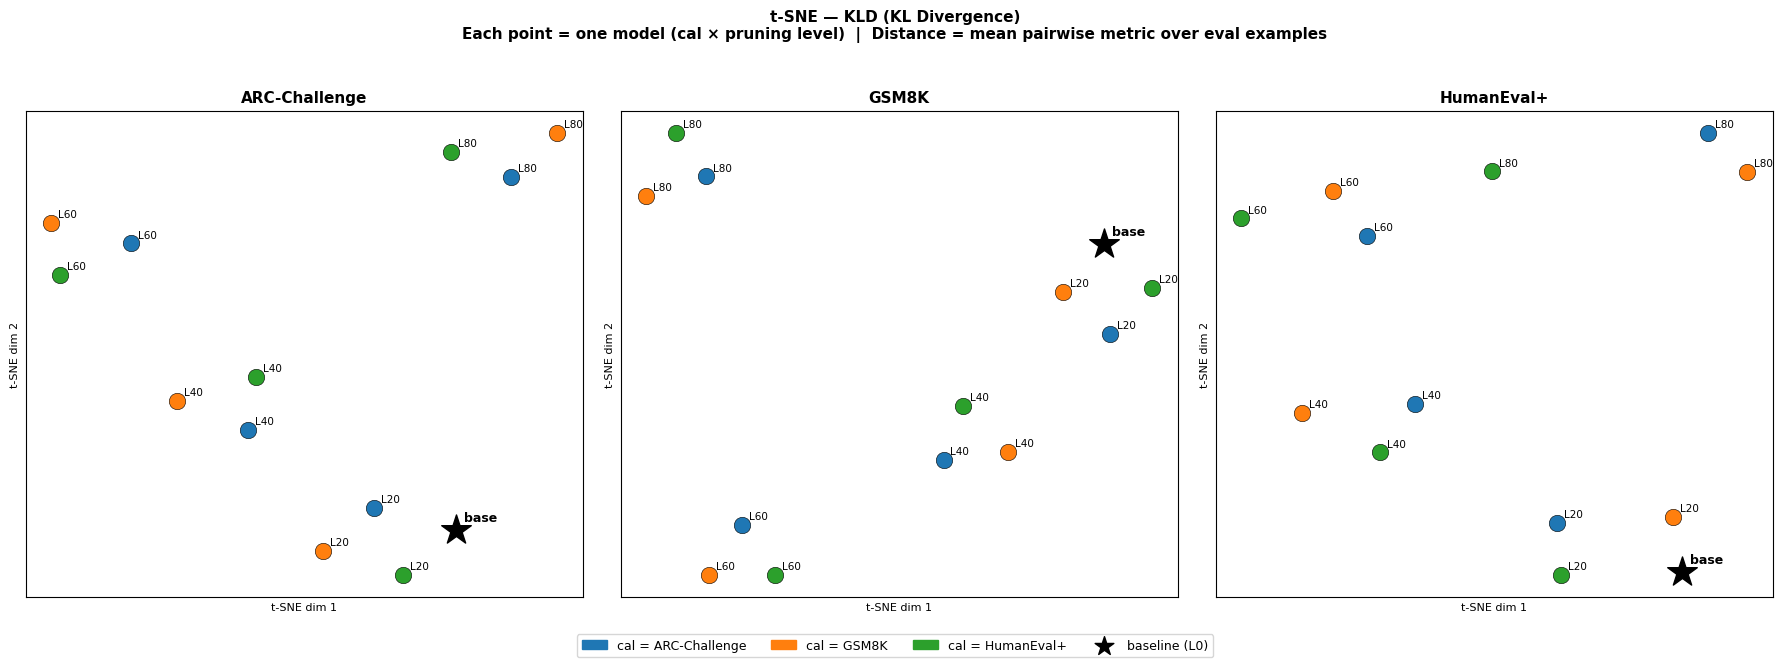

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/tsne_figures/tsne_jsd.png


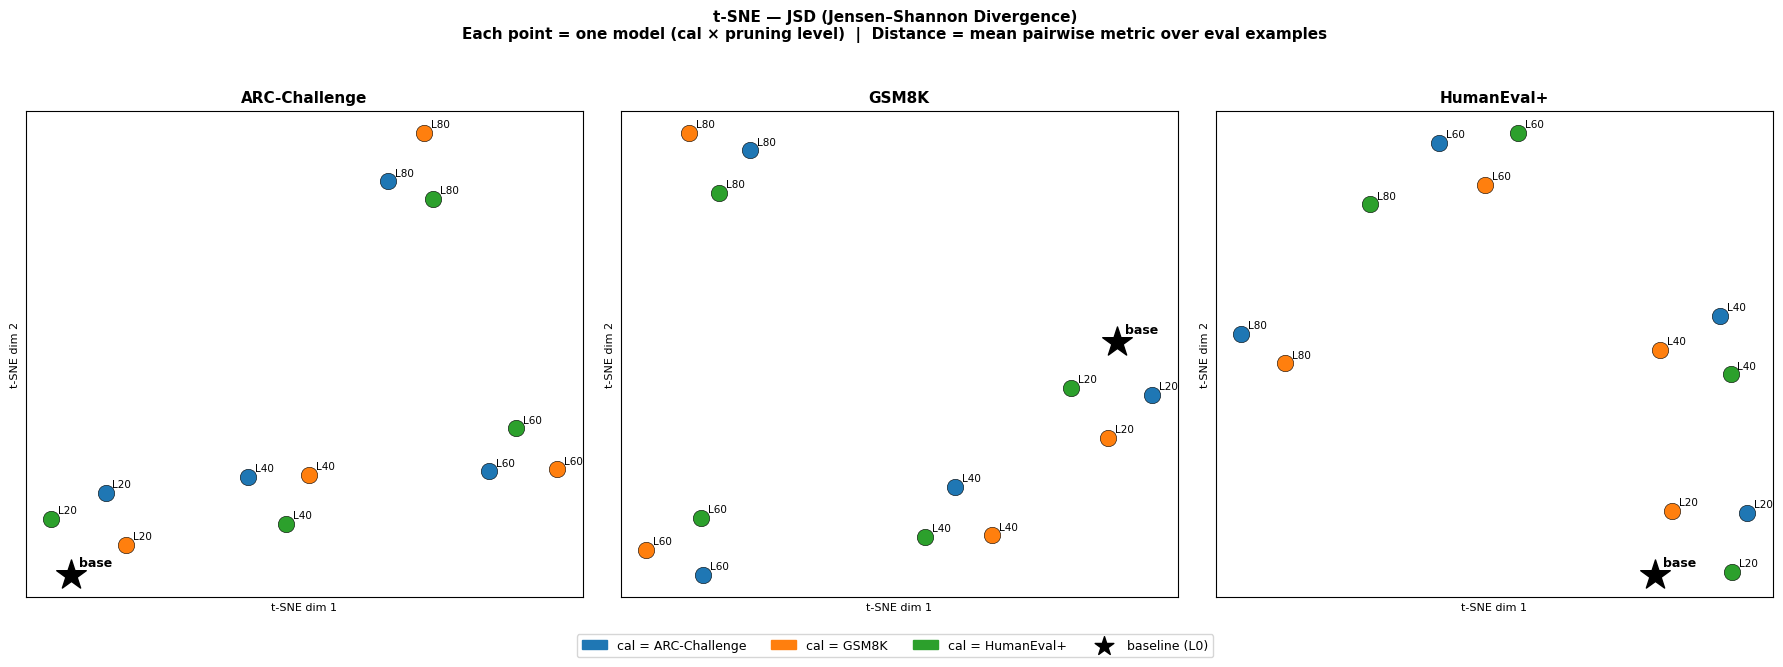

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/tsne_figures/tsne_emd.png


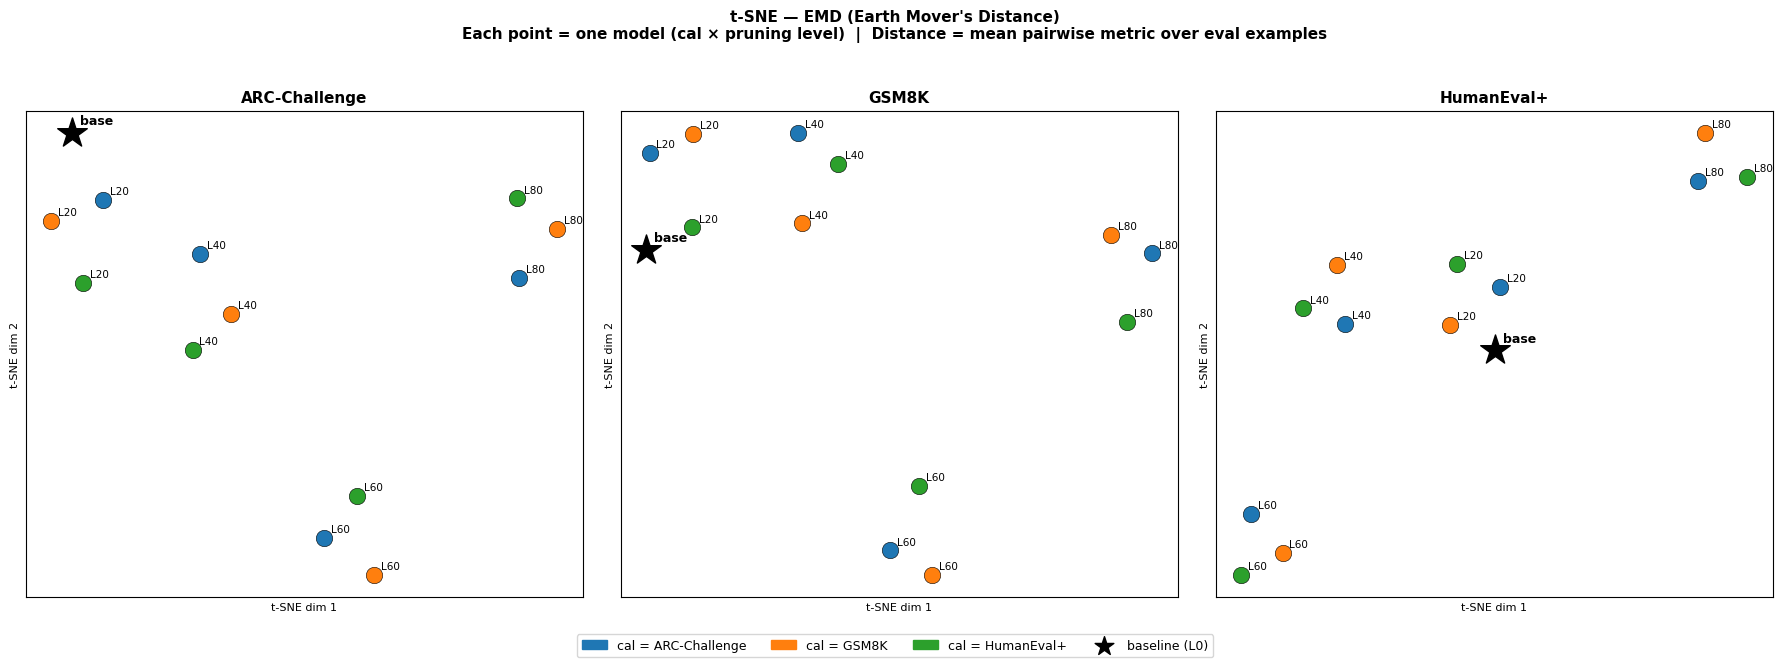

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/tsne_figures/tsne_chamfer.png


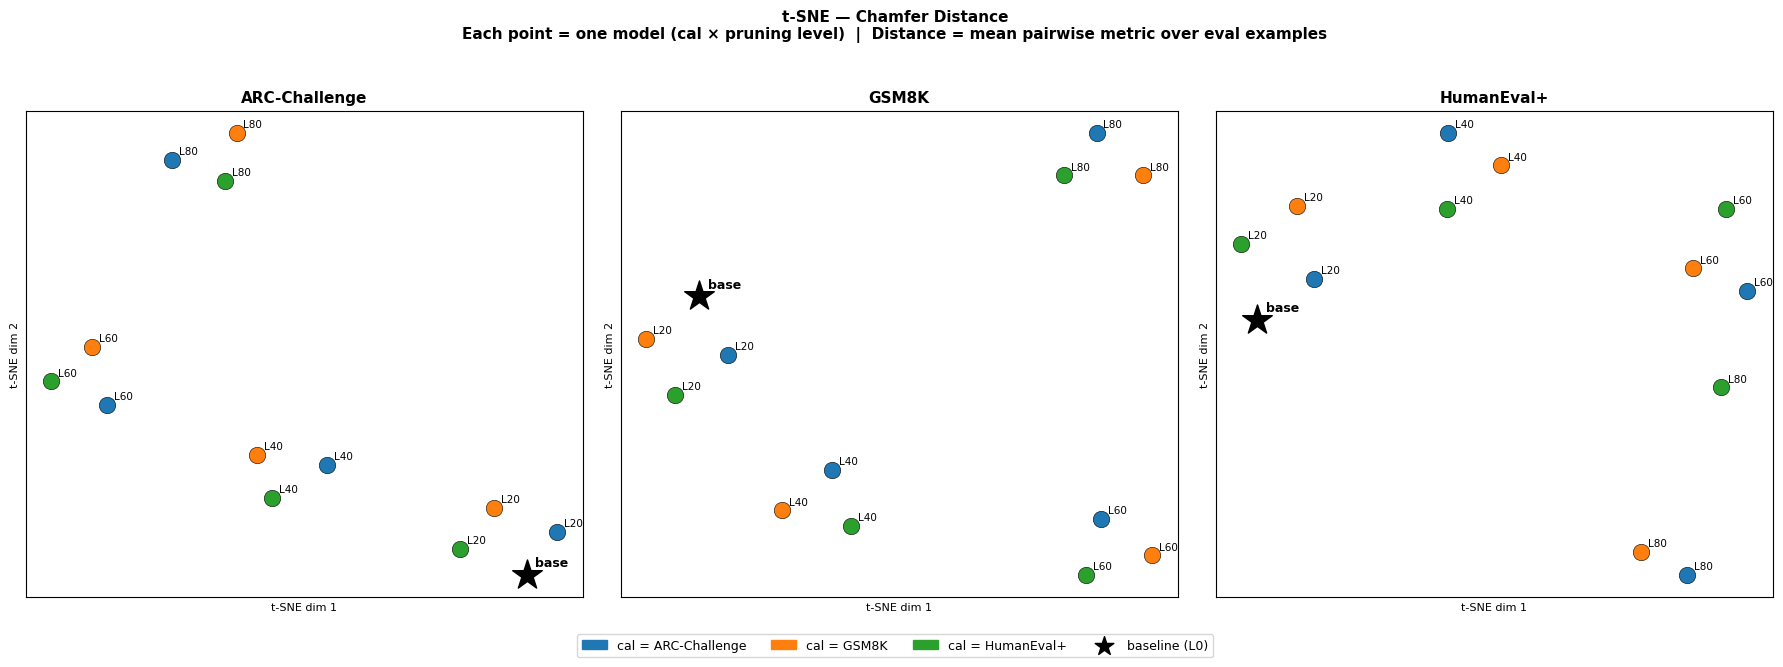

In [9]:
FIGURES_DIR = RESULTS_DIR / "tsne_figures"
FIGURES_DIR.mkdir(exist_ok=True)

METRIC_TITLES = {
    "kld":     "KLD (KL Divergence)",
    "jsd":     "JSD (Jensen–Shannon Divergence)",
    "emd":     "EMD (Earth Mover's Distance)",
    "chamfer": "Chamfer Distance",
}

for metric_name in METRIC_NAMES:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, eval_bench in zip(axes, DATASETS):
        emb      = tsne_results[eval_bench][metric_name]
        row_meta = pairwise_matrices[eval_bench][metric_name][1]

        ax.scatter(
            emb[0, 0], emb[0, 1],
            c="black", marker="*", s=500,
            zorder=5,
        )
        ax.annotate(
            "base", (emb[0, 0], emb[0, 1]),
            xytext=(6, 6), textcoords="offset points",
            fontsize=9, fontweight="bold",
        )
        for i, meta in enumerate(row_meta[1:], start=1):
            color = CAL_COLORS[meta["cal"]]
            ax.scatter(
                emb[i, 0], emb[i, 1],
                c=color, s=140,
                zorder=3, edgecolors="k", linewidths=0.4,
            )
            ax.annotate(
                f"L{meta['level']}", (emb[i, 0], emb[i, 1]),
                xytext=(5, 4), textcoords="offset points", fontsize=7.5,
            )

        ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=11, fontweight="bold")
        ax.set_xlabel("t-SNE dim 1", fontsize=8)
        ax.set_ylabel("t-SNE dim 2", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    legend_handles = [
        mpatches.Patch(color=CAL_COLORS[cal], label=f"cal = {BENCHMARK_LABELS[cal]}")
        for cal in DATASETS
    ]
    legend_handles.append(plt.scatter([], [], c="black", marker="*", s=200, label="baseline (L0)"))
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=4, fontsize=9,
        bbox_to_anchor=(0.5, -0.06), frameon=True,
    )
    fig.suptitle(
        f"t-SNE — {METRIC_TITLES[metric_name]}\n"
        "Each point = one model (cal × pruning level)  |  "
        "Distance = mean pairwise metric over eval examples",
        fontsize=11, fontweight="bold", y=1.03,
    )
    fig.tight_layout()
    out_path = FIGURES_DIR / f"tsne_{metric_name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

## Combined summary figure (4 × 3)

All 12 panels in one figure for side-by-side comparison across metrics and benchmarks.

Saved summary: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/tsne_figures/tsne_summary_all.png


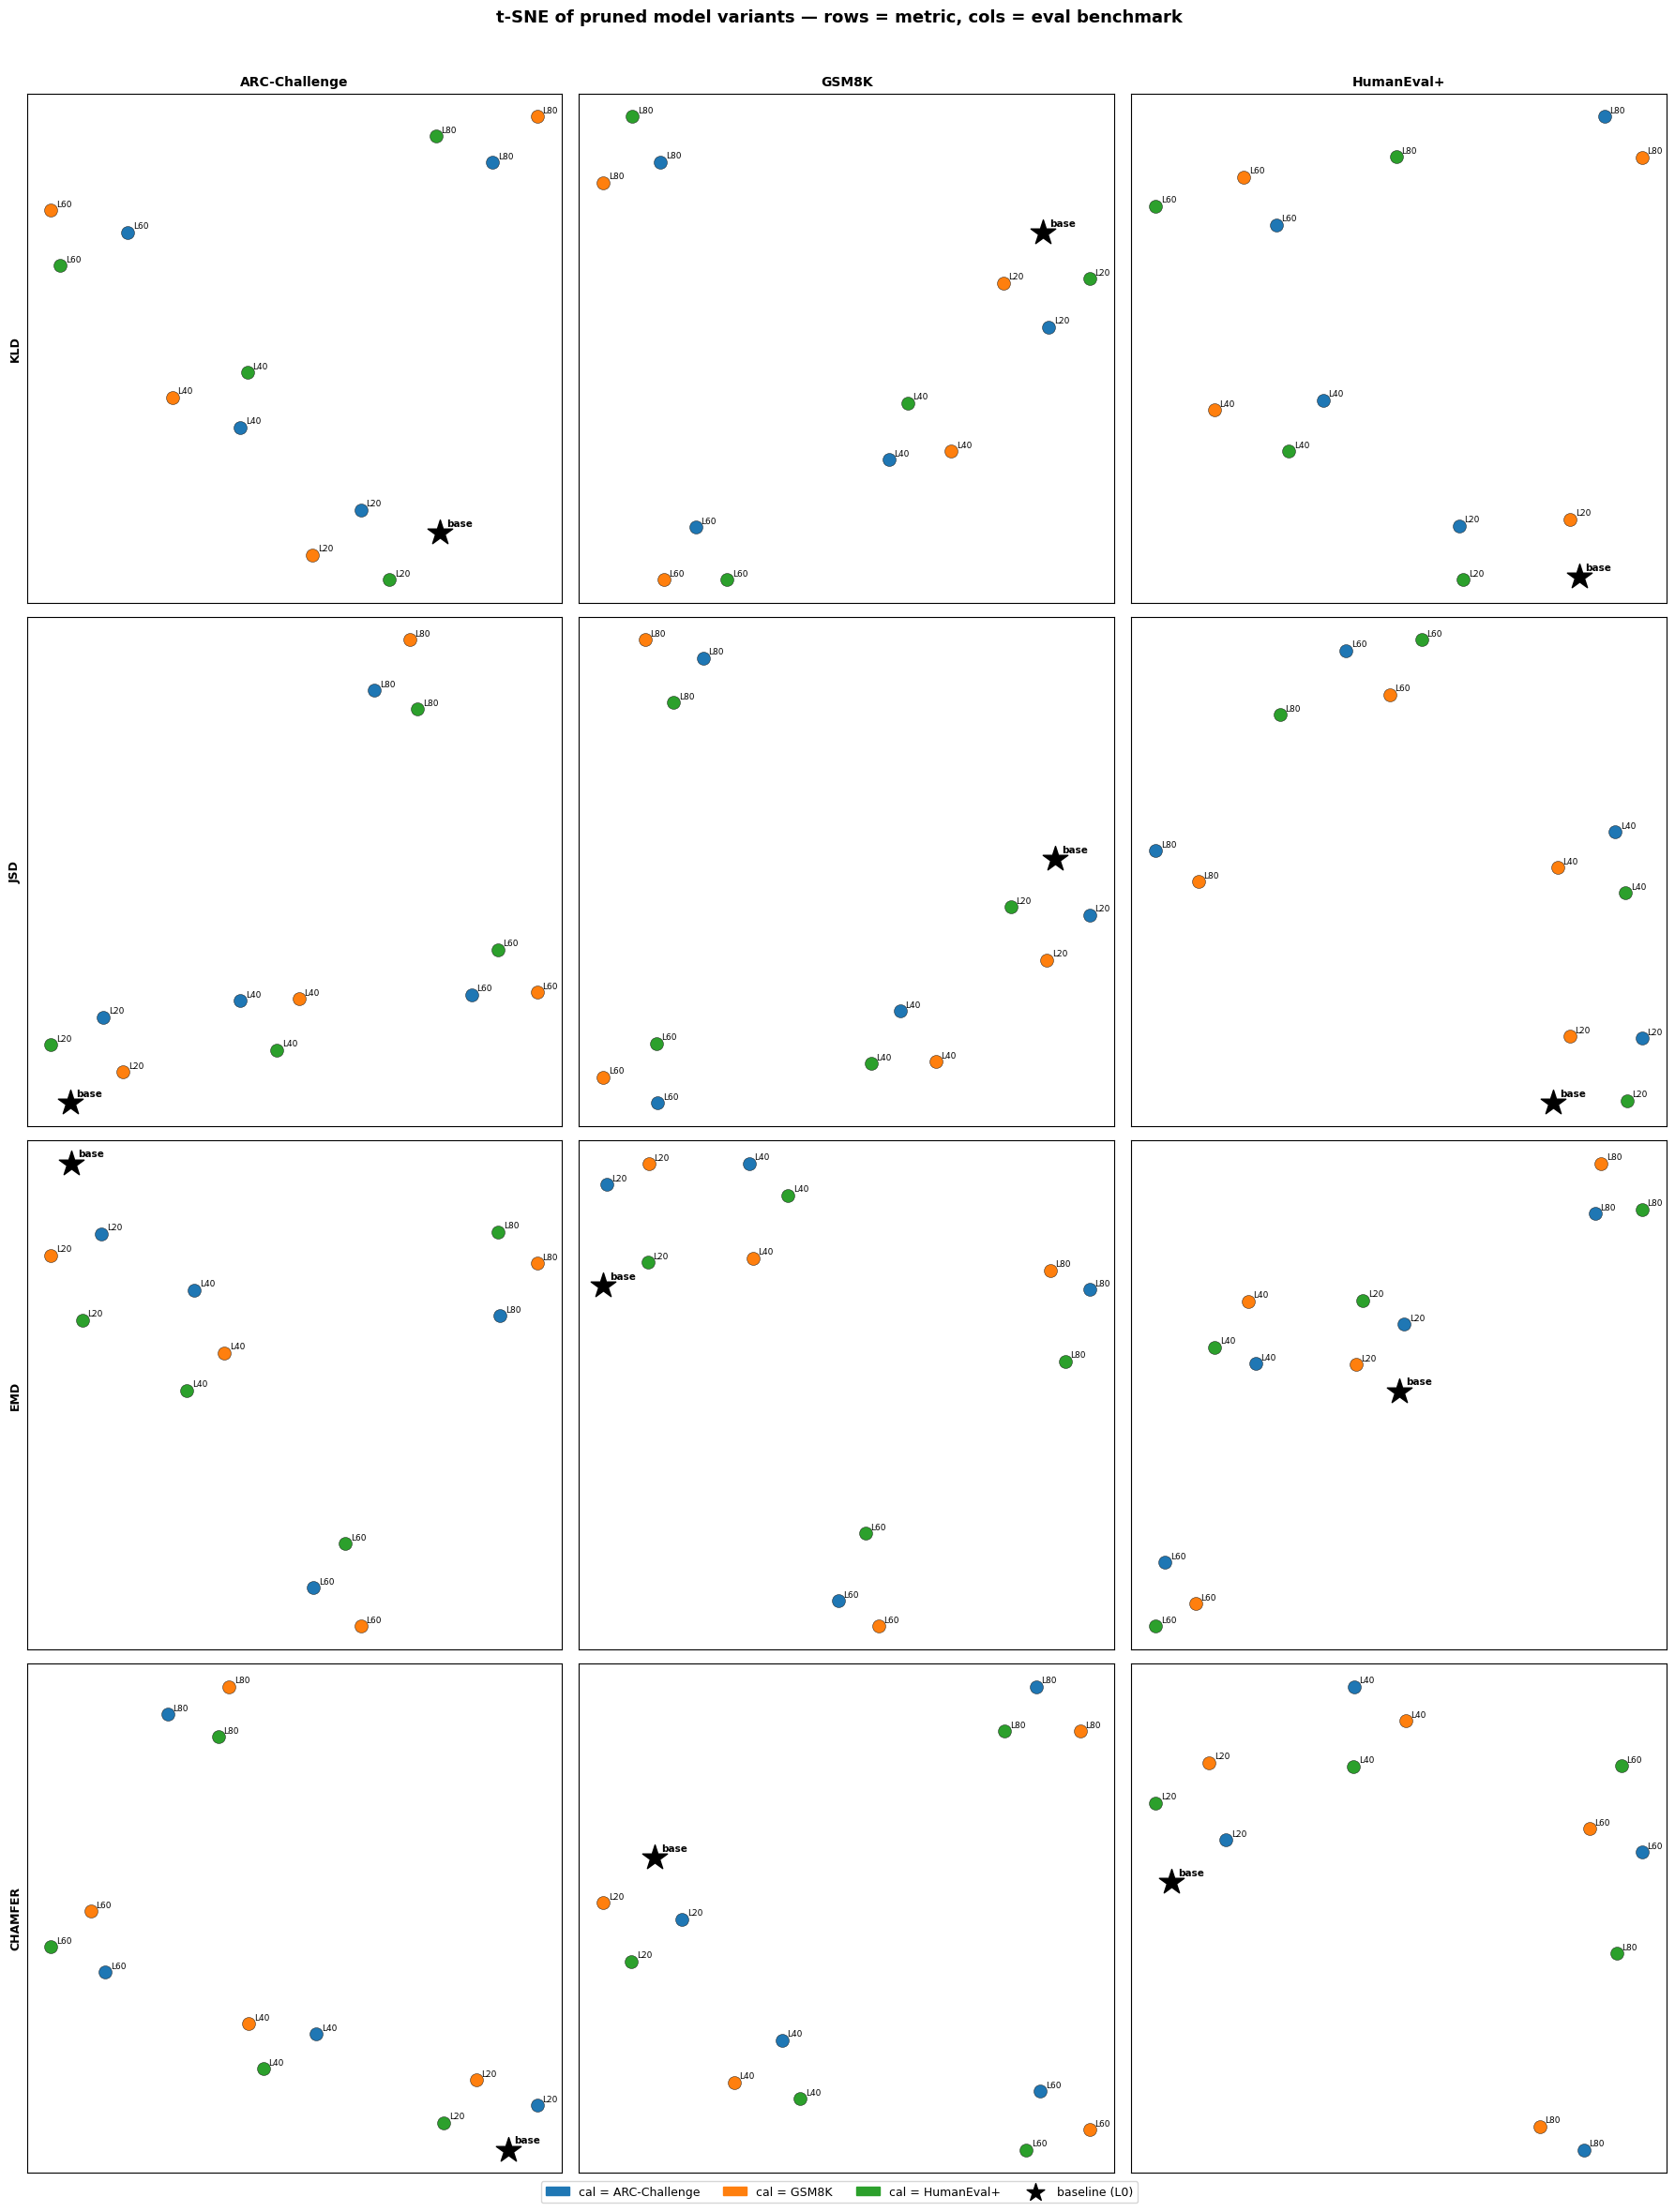

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(18, 23))

for row_idx, metric_name in enumerate(METRIC_NAMES):
    for col_idx, eval_bench in enumerate(DATASETS):
        ax       = axes[row_idx, col_idx]
        emb      = tsne_results[eval_bench][metric_name]
        row_meta = pairwise_matrices[eval_bench][metric_name][1]

        ax.scatter(emb[0, 0], emb[0, 1], c="black", marker="*", s=400, zorder=5)
        ax.annotate(
            "base", (emb[0, 0], emb[0, 1]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7.5, fontweight="bold",
        )
        for i, meta in enumerate(row_meta[1:], start=1):
            ax.scatter(
                emb[i, 0], emb[i, 1],
                c=CAL_COLORS[meta["cal"]], s=100,
                zorder=3, edgecolors="k", linewidths=0.3,
            )
            ax.annotate(
                f"L{meta['level']}", (emb[i, 0], emb[i, 1]),
                xytext=(4, 3), textcoords="offset points", fontsize=6.5,
            )
        if row_idx == 0:
            ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(metric_name.upper(), fontsize=9, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

legend_handles = [
    mpatches.Patch(color=CAL_COLORS[cal], label=f"cal = {BENCHMARK_LABELS[cal]}")
    for cal in DATASETS
]
legend_handles.append(plt.scatter([], [], c="black", marker="*", s=200, label="baseline (L0)"))
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "t-SNE of pruned model variants — rows = metric, cols = eval benchmark",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
out_path = FIGURES_DIR / "tsne_summary_all.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
print(f"Saved summary: {out_path}")
plt.show()

## UMAP

Same pairwise-distance design as the t-SNE section above, using UMAP for dimensionality reduction.

**Parameters**:
- `n_neighbors=4`: neighbourhood size (< 13 points); controls local vs global structure trade-off
- `min_dist=0.3`: minimum distance between embedded points
- `metric="precomputed"`: input is the 13×13 pairwise distance matrix

In [11]:
try:
    import umap
    print("umap-learn already installed.")
except ImportError:
    print("Installing umap-learn ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn"], check=True)
    import umap
    print("umap-learn installed.")

/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


umap-learn already installed.


In [12]:
umap_results: dict[str, dict[str, np.ndarray]] = {}

for eval_bench in DATASETS:
    umap_results[eval_bench] = {}
    for metric_name in METRIC_NAMES:
        D, row_meta = pairwise_matrices[eval_bench][metric_name]

        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=4,
            min_dist=0.3,
            metric="precomputed",
            random_state=42,
        )
        emb = reducer.fit_transform(D)
        umap_results[eval_bench][metric_name] = emb
        print(f"  {eval_bench}/{metric_name}: done")

/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  arc_challenge/kld: done
  arc_challenge/jsd: done
  arc_challenge/emd: done
  arc_challenge/chamfer: done
  gsm8k/kld: done
  gsm8k/jsd: done
  gsm8k/emd: done
  gsm8k/chamfer: done
  humaneval/kld: done
  humaneval/jsd: done
  humaneval/emd: done
  humaneval/chamfer: done


/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/home/three-kingdoms/work/pruning-metrics/.venv/lib64/python3.14/site-

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/umap_figures/umap_kld.png


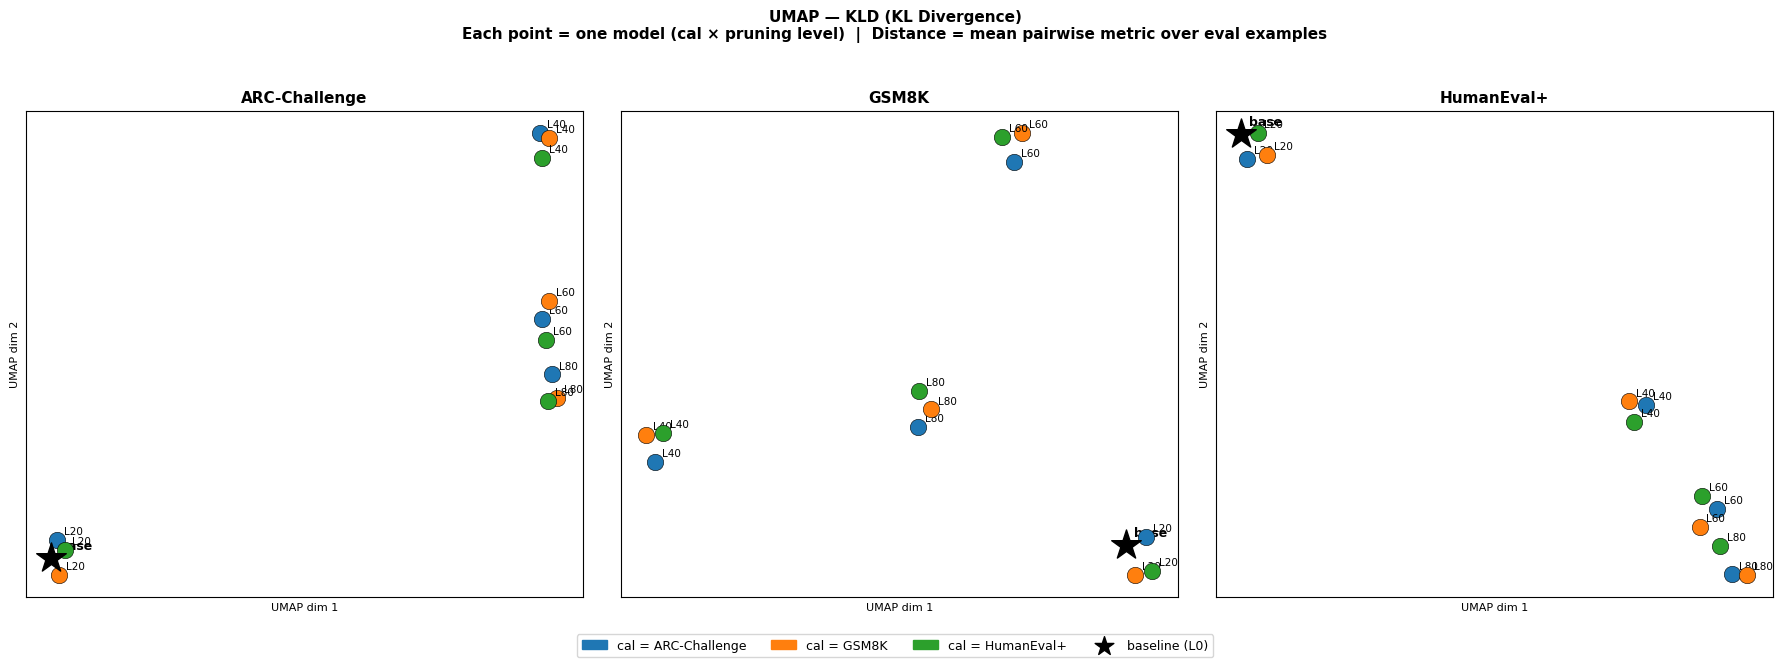

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/umap_figures/umap_jsd.png


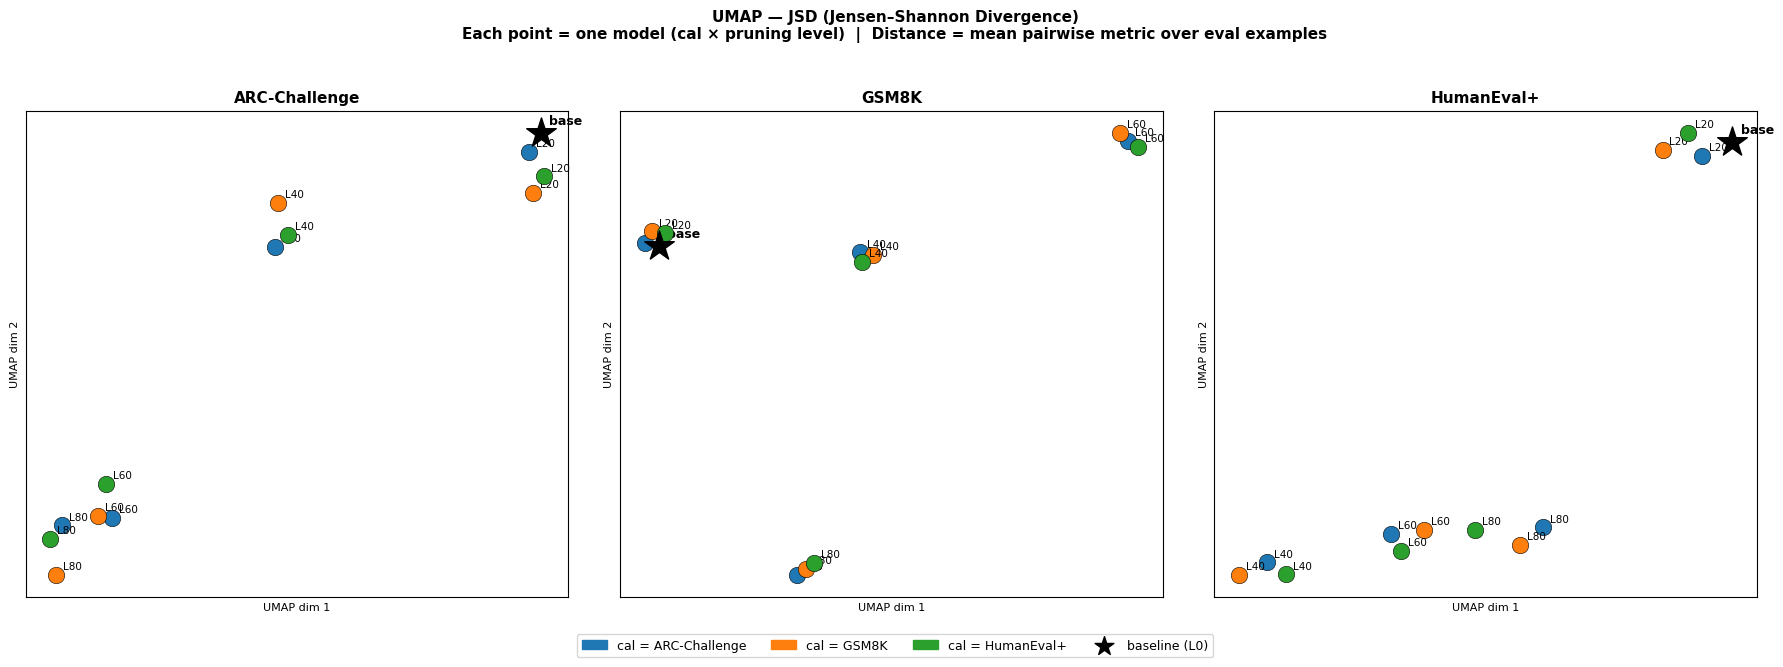

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/umap_figures/umap_emd.png


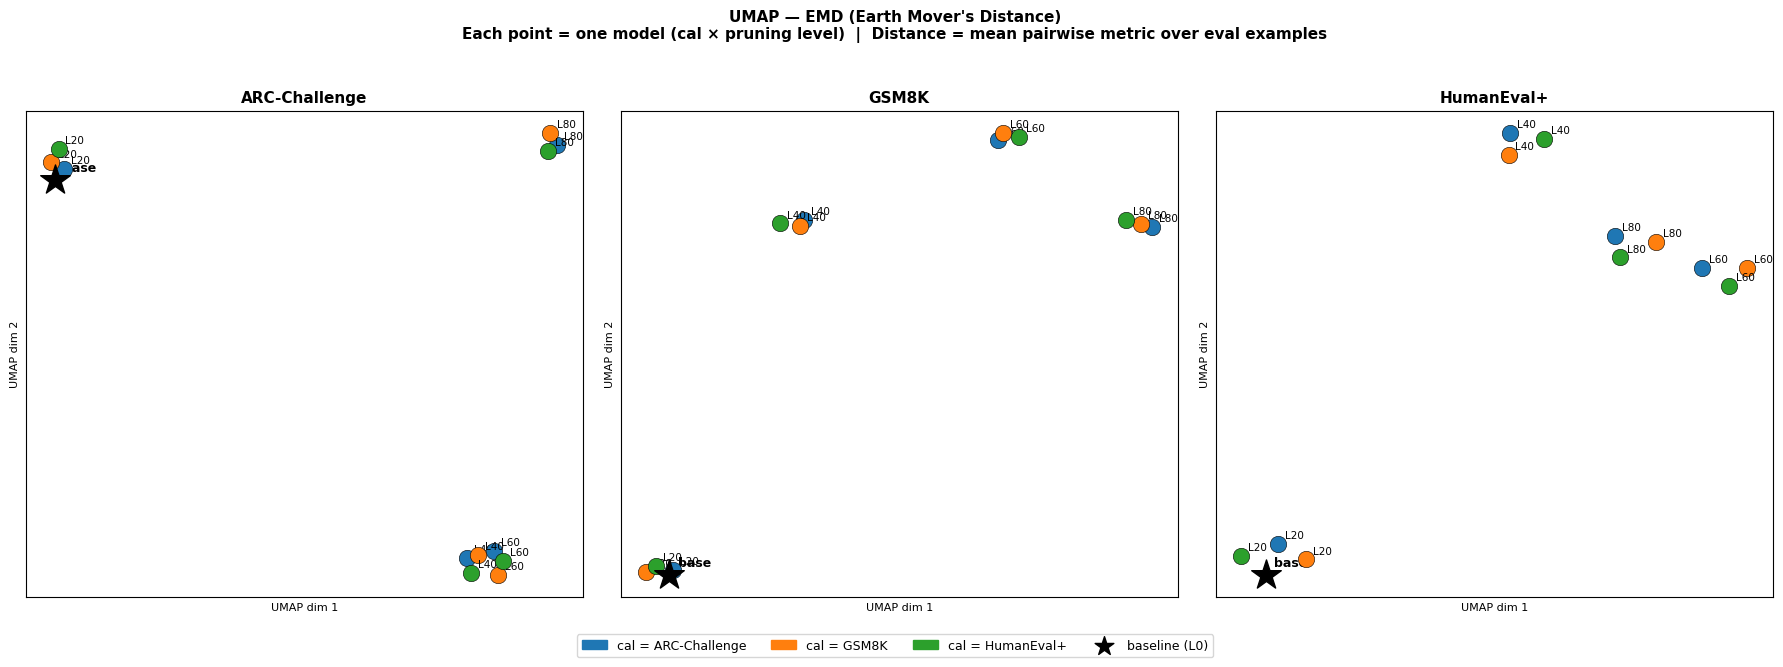

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/umap_figures/umap_chamfer.png


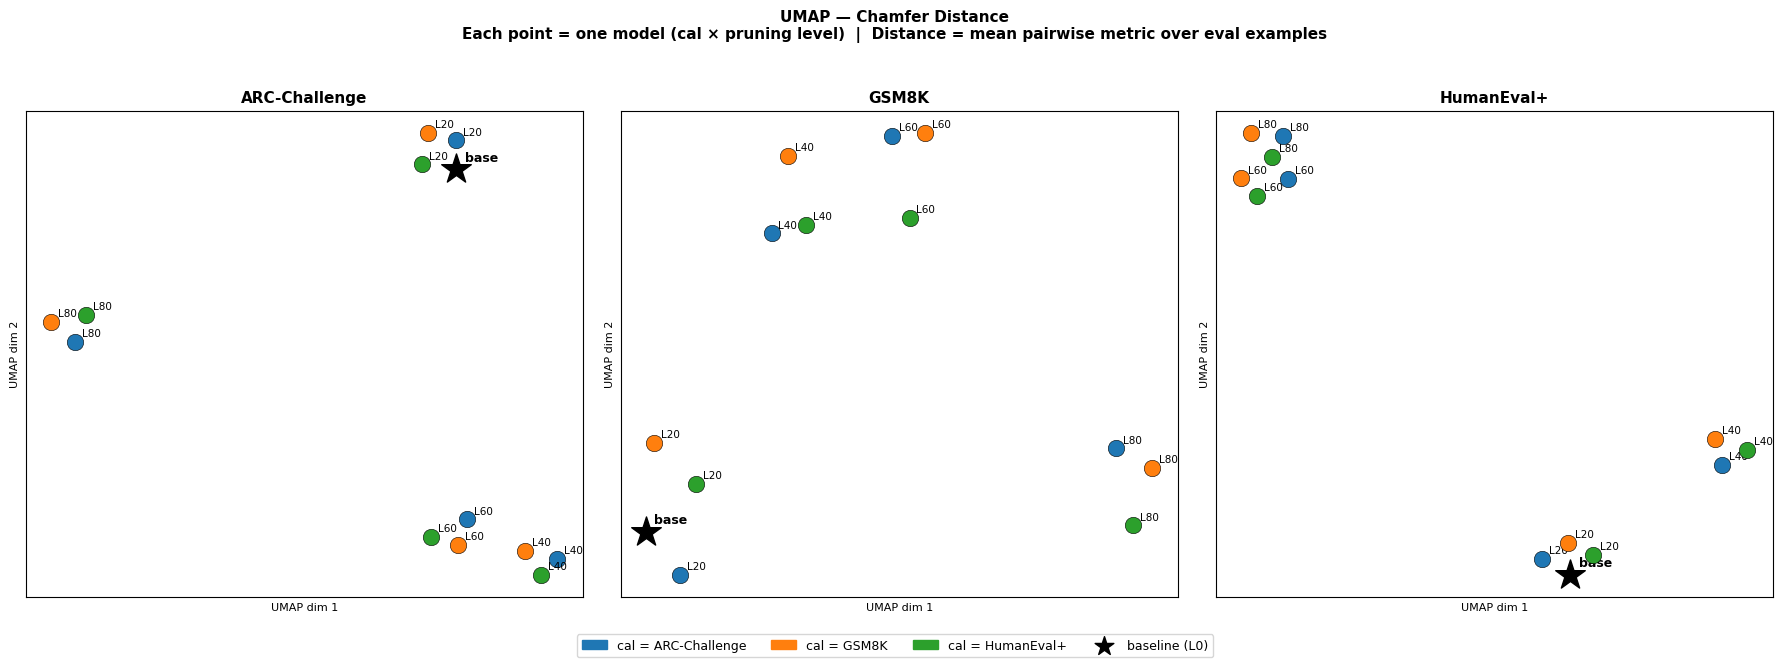

In [13]:
UMAP_FIGURES_DIR = RESULTS_DIR / "umap_figures"
UMAP_FIGURES_DIR.mkdir(exist_ok=True)

for metric_name in METRIC_NAMES:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, eval_bench in zip(axes, DATASETS):
        emb      = umap_results[eval_bench][metric_name]
        row_meta = pairwise_matrices[eval_bench][metric_name][1]

        ax.scatter(
            emb[0, 0], emb[0, 1],
            c="black", marker="*", s=500, zorder=5,
        )
        ax.annotate(
            "base", (emb[0, 0], emb[0, 1]),
            xytext=(6, 6), textcoords="offset points",
            fontsize=9, fontweight="bold",
        )
        for i, meta in enumerate(row_meta[1:], start=1):
            ax.scatter(
                emb[i, 0], emb[i, 1],
                c=CAL_COLORS[meta["cal"]], s=140,
                zorder=3, edgecolors="k", linewidths=0.4,
            )
            ax.annotate(
                f"L{meta['level']}", (emb[i, 0], emb[i, 1]),
                xytext=(5, 4), textcoords="offset points", fontsize=7.5,
            )

        ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=11, fontweight="bold")
        ax.set_xlabel("UMAP dim 1", fontsize=8)
        ax.set_ylabel("UMAP dim 2", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    legend_handles = [
        mpatches.Patch(color=CAL_COLORS[cal], label=f"cal = {BENCHMARK_LABELS[cal]}")
        for cal in DATASETS
    ]
    legend_handles.append(plt.scatter([], [], c="black", marker="*", s=200, label="baseline (L0)"))
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=4, fontsize=9,
        bbox_to_anchor=(0.5, -0.06), frameon=True,
    )
    fig.suptitle(
        f"UMAP — {METRIC_TITLES[metric_name]}\n"
        "Each point = one model (cal × pruning level)  |  "
        "Distance = mean pairwise metric over eval examples",
        fontsize=11, fontweight="bold", y=1.03,
    )
    fig.tight_layout()
    out_path = UMAP_FIGURES_DIR / f"umap_{metric_name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

Saved summary: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/umap_figures/umap_summary_all.png


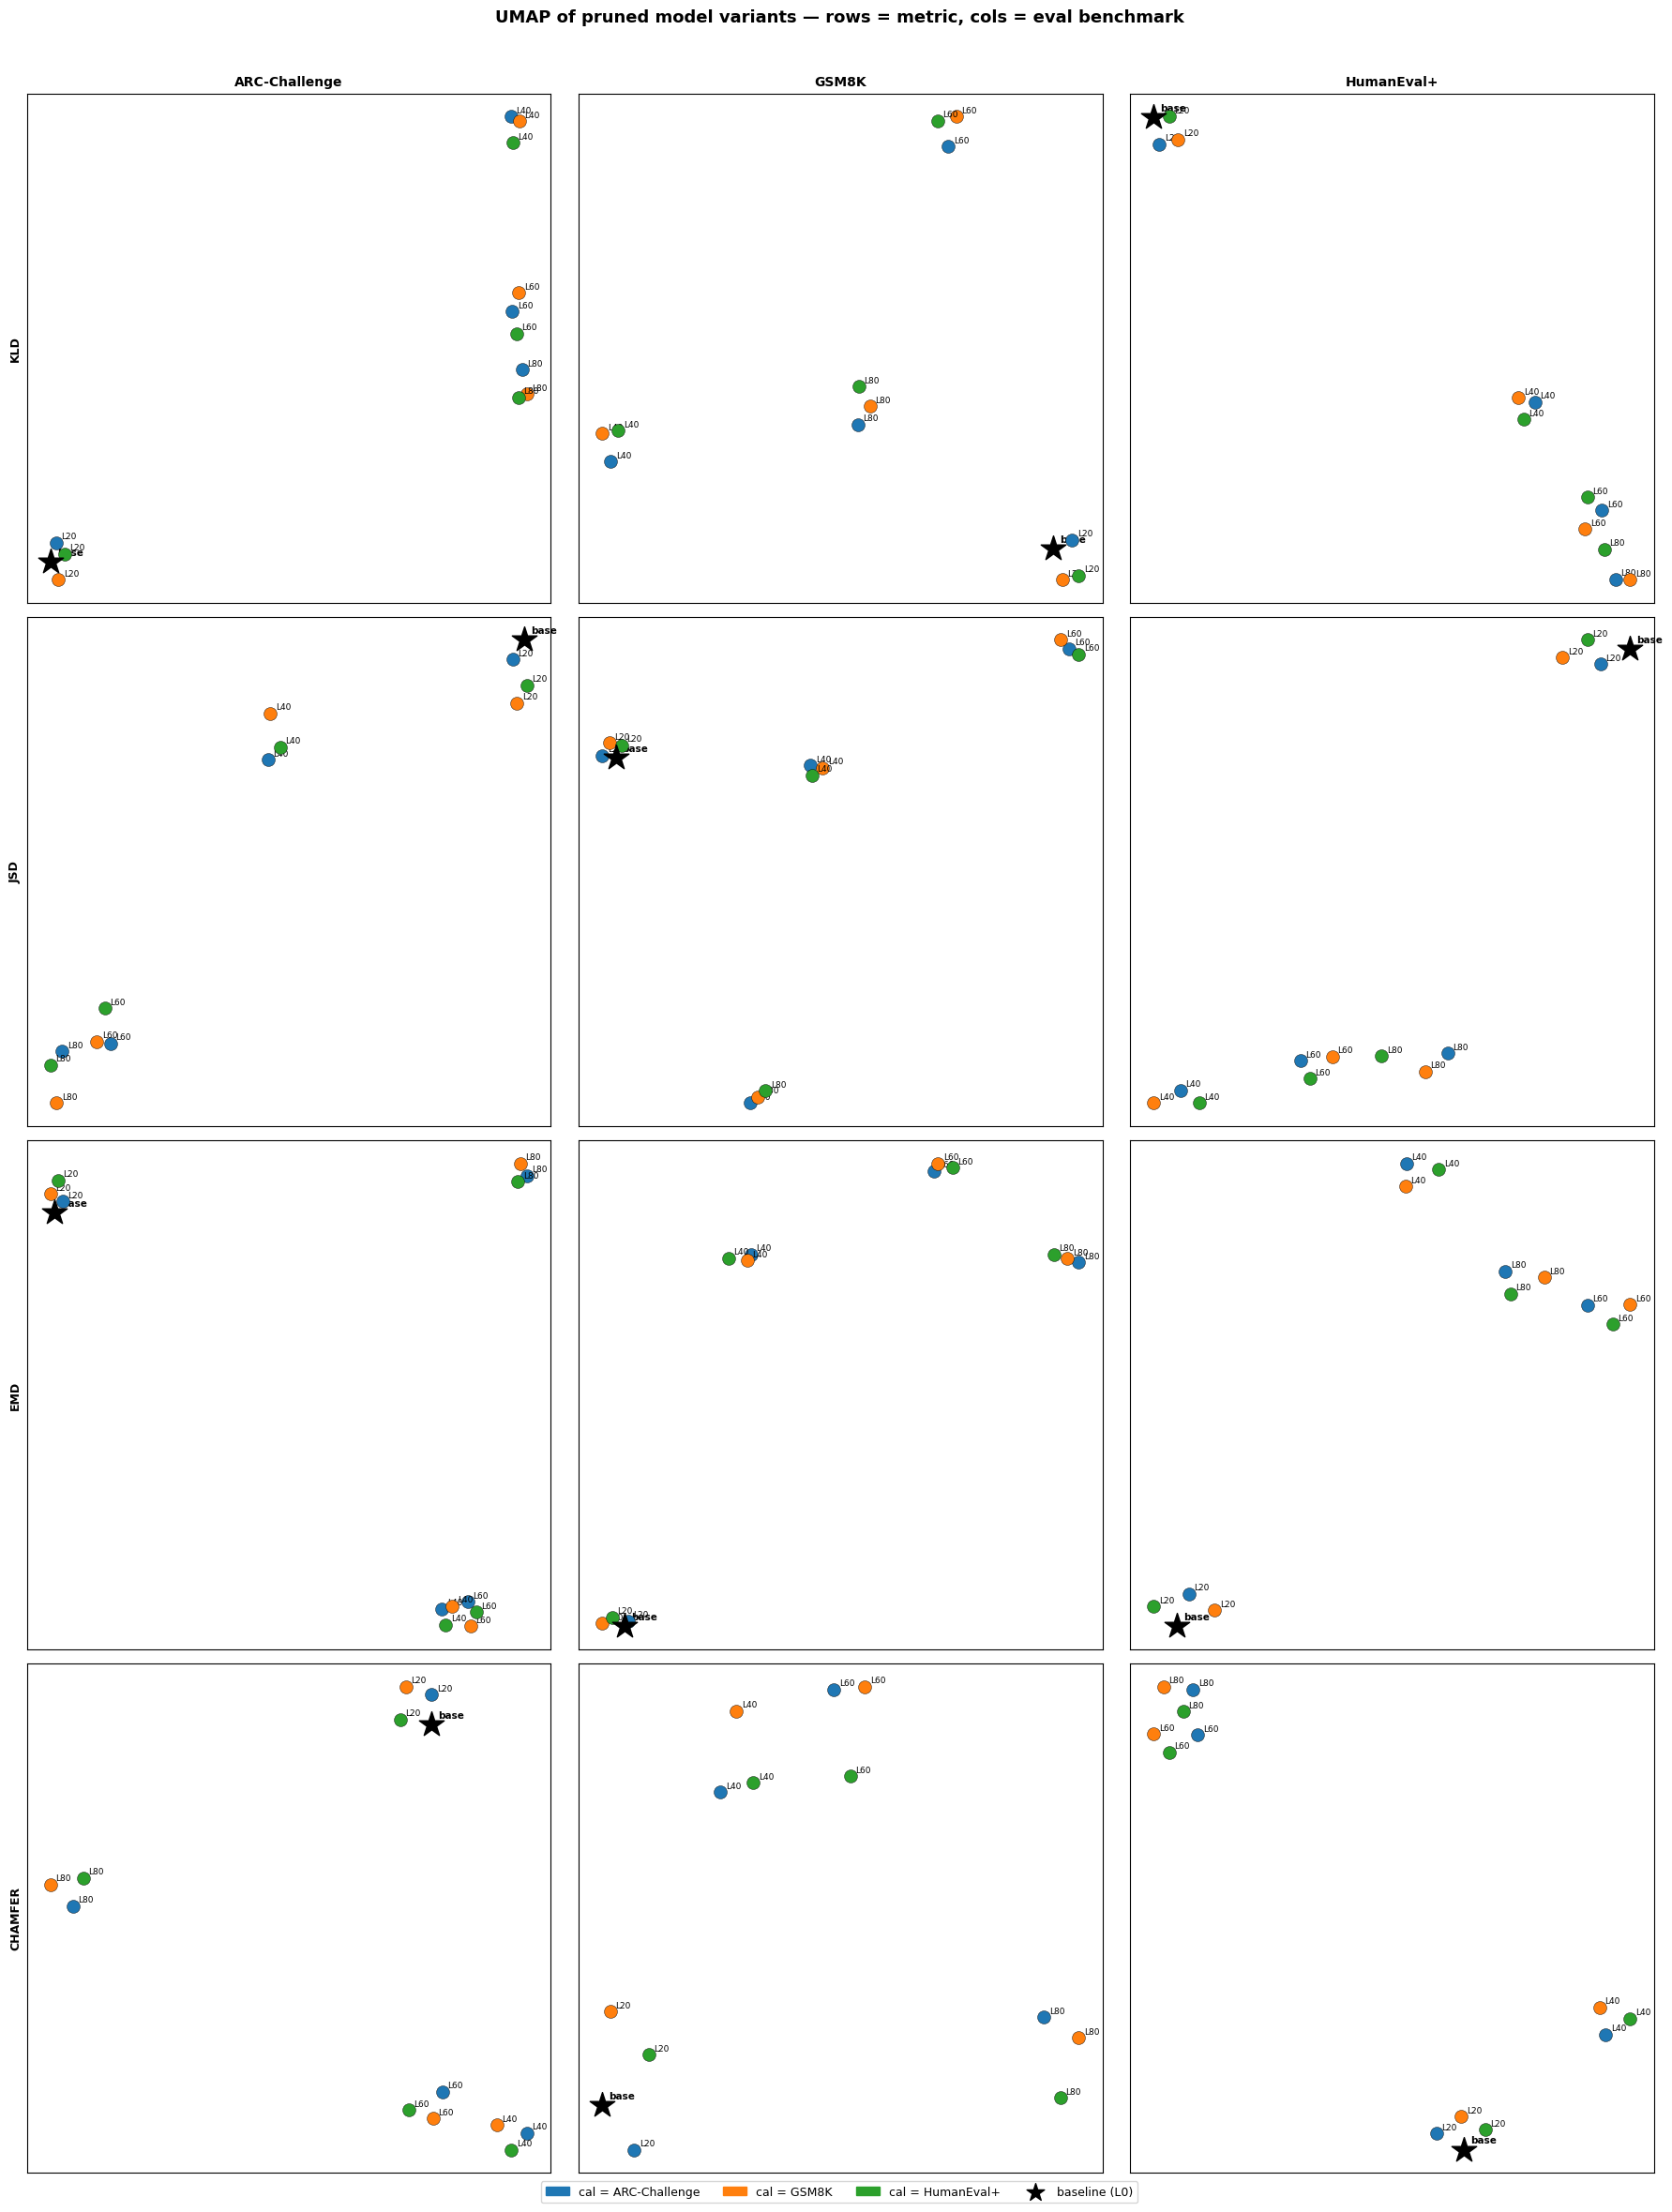

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(18, 23))

for row_idx, metric_name in enumerate(METRIC_NAMES):
    for col_idx, eval_bench in enumerate(DATASETS):
        ax       = axes[row_idx, col_idx]
        emb      = umap_results[eval_bench][metric_name]
        row_meta = pairwise_matrices[eval_bench][metric_name][1]

        ax.scatter(emb[0, 0], emb[0, 1], c="black", marker="*", s=400, zorder=5)
        ax.annotate(
            "base", (emb[0, 0], emb[0, 1]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7.5, fontweight="bold",
        )
        for i, meta in enumerate(row_meta[1:], start=1):
            ax.scatter(
                emb[i, 0], emb[i, 1],
                c=CAL_COLORS[meta["cal"]], s=100,
                zorder=3, edgecolors="k", linewidths=0.3,
            )
            ax.annotate(
                f"L{meta['level']}", (emb[i, 0], emb[i, 1]),
                xytext=(4, 3), textcoords="offset points", fontsize=6.5,
            )
        if row_idx == 0:
            ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(metric_name.upper(), fontsize=9, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

legend_handles = [
    mpatches.Patch(color=CAL_COLORS[cal], label=f"cal = {BENCHMARK_LABELS[cal]}")
    for cal in DATASETS
]
legend_handles.append(plt.scatter([], [], c="black", marker="*", s=200, label="baseline (L0)"))
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "UMAP of pruned model variants — rows = metric, cols = eval benchmark",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
out_path = UMAP_FIGURES_DIR / "umap_summary_all.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
print(f"Saved summary: {out_path}")
plt.show()

## Isolating the Calibration Signal

The tSNE/UMAP above clusters by pruning level because within-level step distances are
1.4–2.4× larger than cross-calibration distances at the same level.  The three analyses
below remove the pruning-level trend so the sub-dominant calibration effect becomes visible:

1. **Per-level bar charts** — distance from baseline grouped by pruning level, 3 bars per group
2. **Centered embeddings** — subtract per-level centroid from tSNE/UMAP so within-level spread fills the frame
3. **Normalized calibration divergence** — cross-cal distance as a fraction of adjacent within-cal step

### 1. Per-level bar charts

For each (eval benchmark × metric), bars are grouped by pruning level with one bar per
calibration source.  If calibration matters within a level, the 3 bars should diverge;
if calibration is irrelevant, they should be equal.

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/bars_kld.png


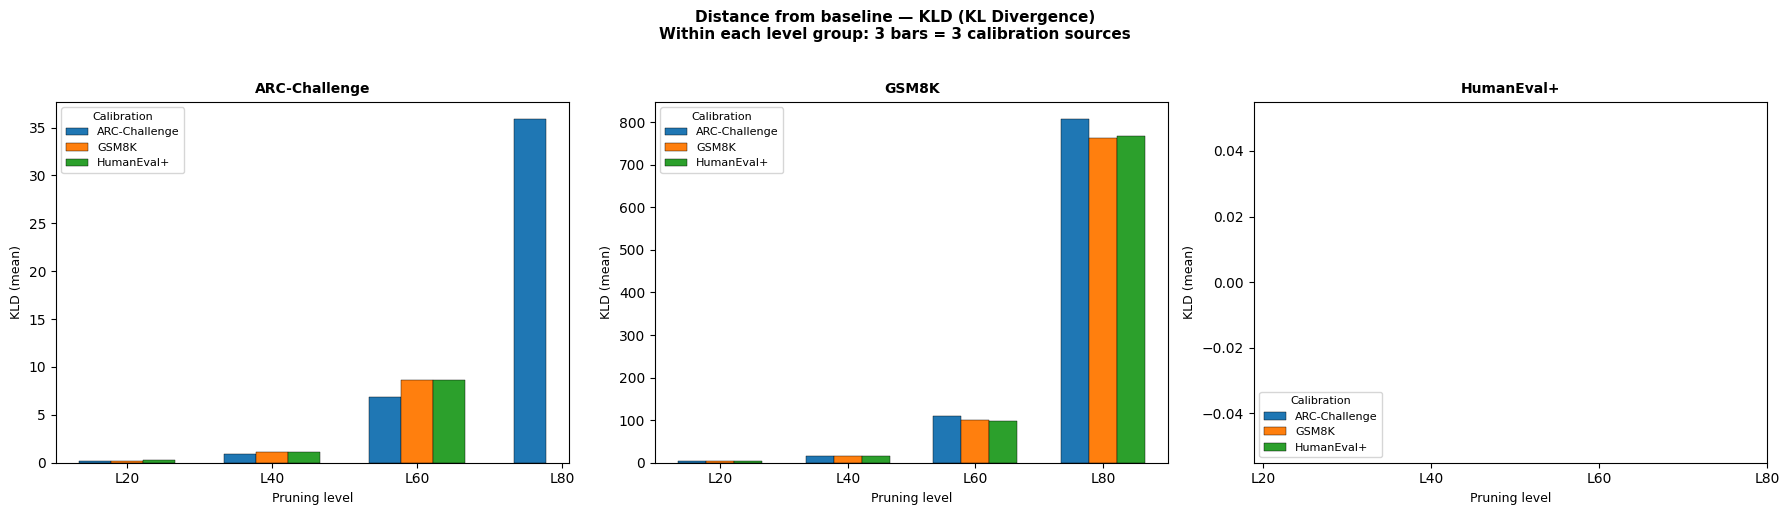

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/bars_jsd.png


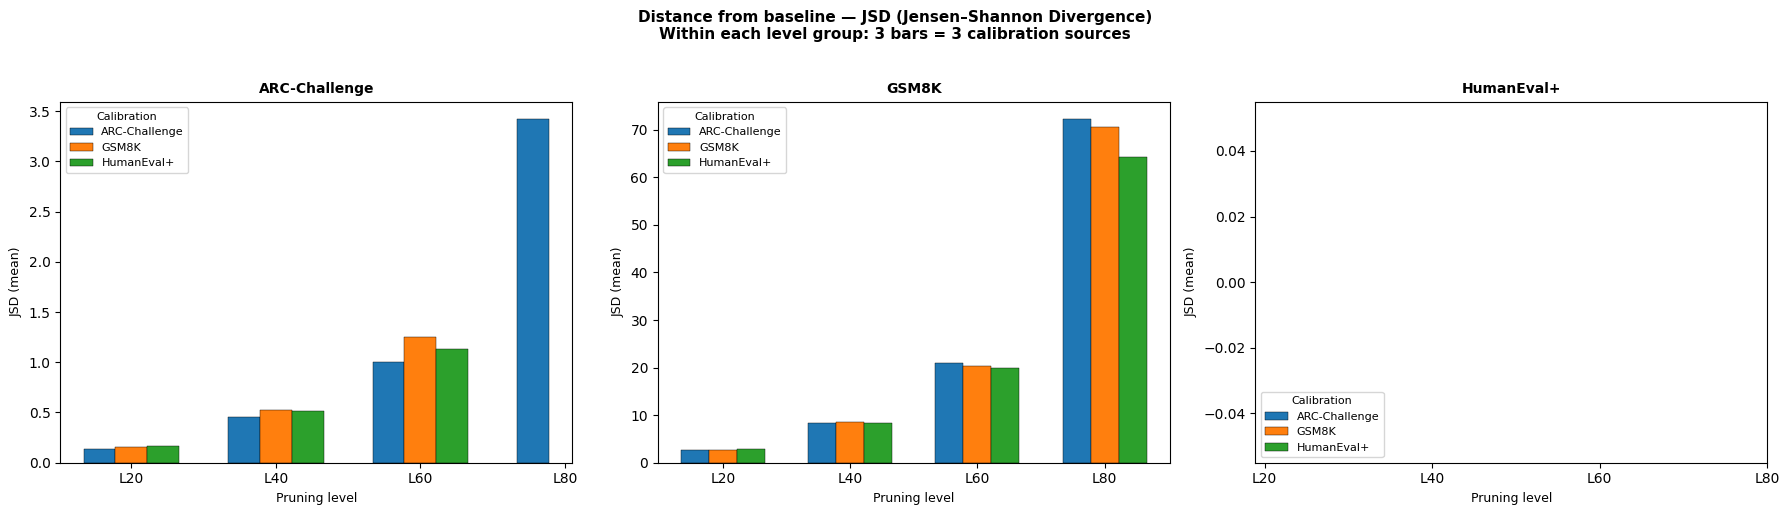

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/bars_emd.png


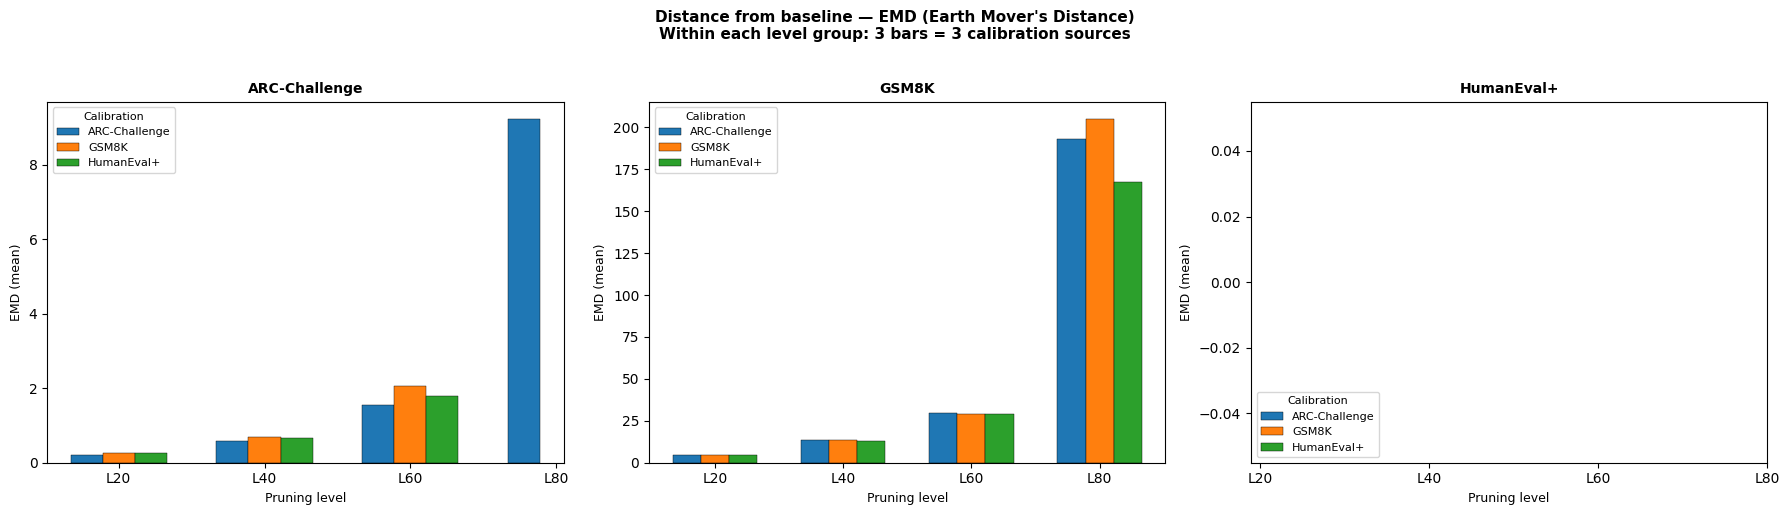

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/bars_chamfer.png


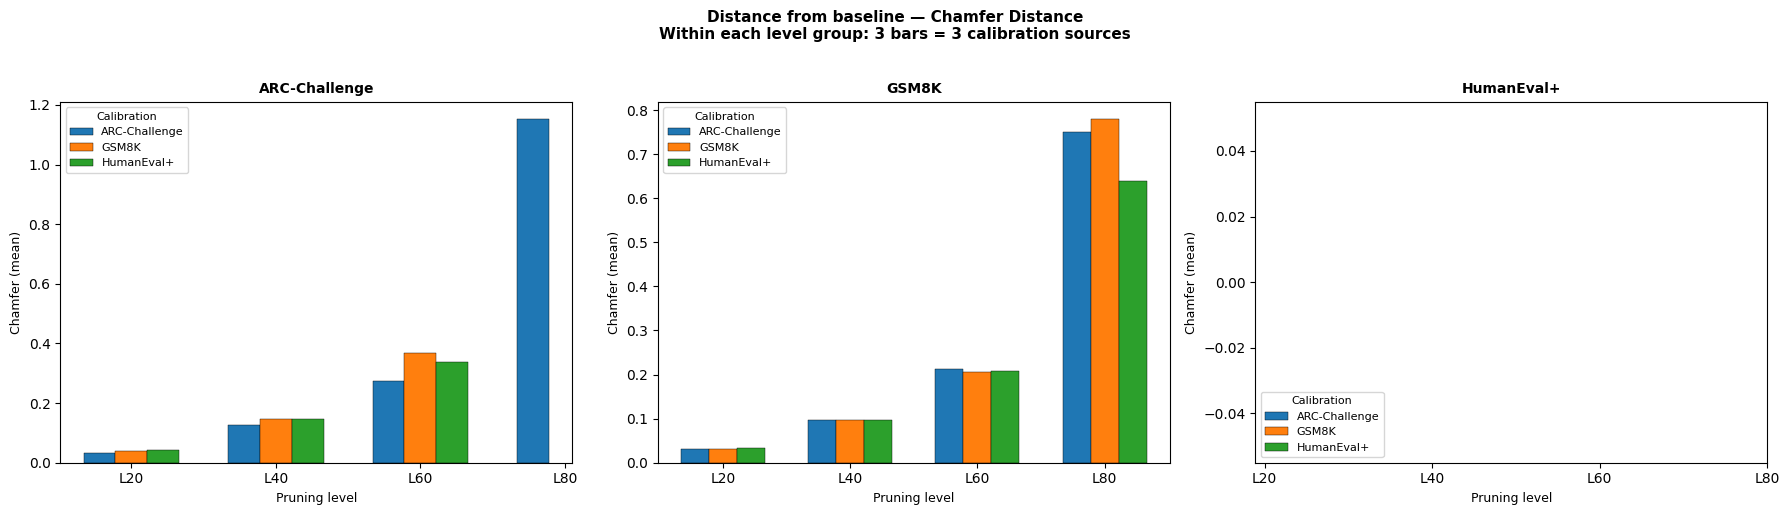

In [15]:
import csv

# Load CSV (no pandas dependency)
with open(RESULTS_DIR / "metric_space_combined.csv") as _f:
    _rows = list(csv.DictReader(_f))

# Only non-baseline rows, filter out small-sample flag
_data = [
    r for r in _rows
    if float(r["pruning_level"]) > 0 and r["small_sample"] == "False"
]

BAR_METRICS = {
    "kld":     ("kld_mean",     "KLD (mean)"),
    "jsd":     ("jsd_mean",     "JSD (mean)"),
    "emd":     ("emd_mean",     "EMD (mean)"),
    "chamfer": ("chamfer_mean", "Chamfer (mean)"),
}

BAR_FIGURES_DIR = RESULTS_DIR / "cal_signal_figures"
BAR_FIGURES_DIR.mkdir(exist_ok=True)

x_levels = [20, 40, 60, 80]
cal_order = ["arc_challenge", "gsm8k", "humaneval"]
n_cals    = len(cal_order)
width     = 0.22
offsets   = np.linspace(-(n_cals - 1) / 2, (n_cals - 1) / 2, n_cals) * width

for metric_name, (col, ylabel) in BAR_METRICS.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, eval_bench in zip(axes, DATASETS):
        bench_rows = {r["cal"]: {} for r in _data if r["eval"] == eval_bench}
        for r in _data:
            if r["eval"] != eval_bench:
                continue
            bench_rows[r["cal"]][int(float(r["pruning_level"]))] = float(r[col])

        x_pos = np.arange(len(x_levels))
        for c_idx, cal in enumerate(cal_order):
            vals = [bench_rows.get(cal, {}).get(lv, float("nan")) for lv in x_levels]
            ax.bar(
                x_pos + offsets[c_idx], vals, width=width,
                color=CAL_COLORS[cal], label=BENCHMARK_LABELS[cal],
                edgecolor="k", linewidth=0.3,
            )

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"L{lv}" for lv in x_levels])
        ax.set_xlabel("Pruning level", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=10, fontweight="bold")
        ax.legend(fontsize=8, title="Calibration", title_fontsize=8)

    fig.suptitle(
        f"Distance from baseline — {METRIC_TITLES[metric_name]}\n"
        "Within each level group: 3 bars = 3 calibration sources",
        fontsize=11, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    out = BAR_FIGURES_DIR / f"bars_{metric_name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


### 2. Centered tSNE / UMAP embeddings

For each pruning level, compute the centroid of the 3 models (one per calibration source)
and subtract it.  The re-centered plot removes the between-level gradient so the
within-level calibration spread fills the frame.

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/tsne_centered_all.png


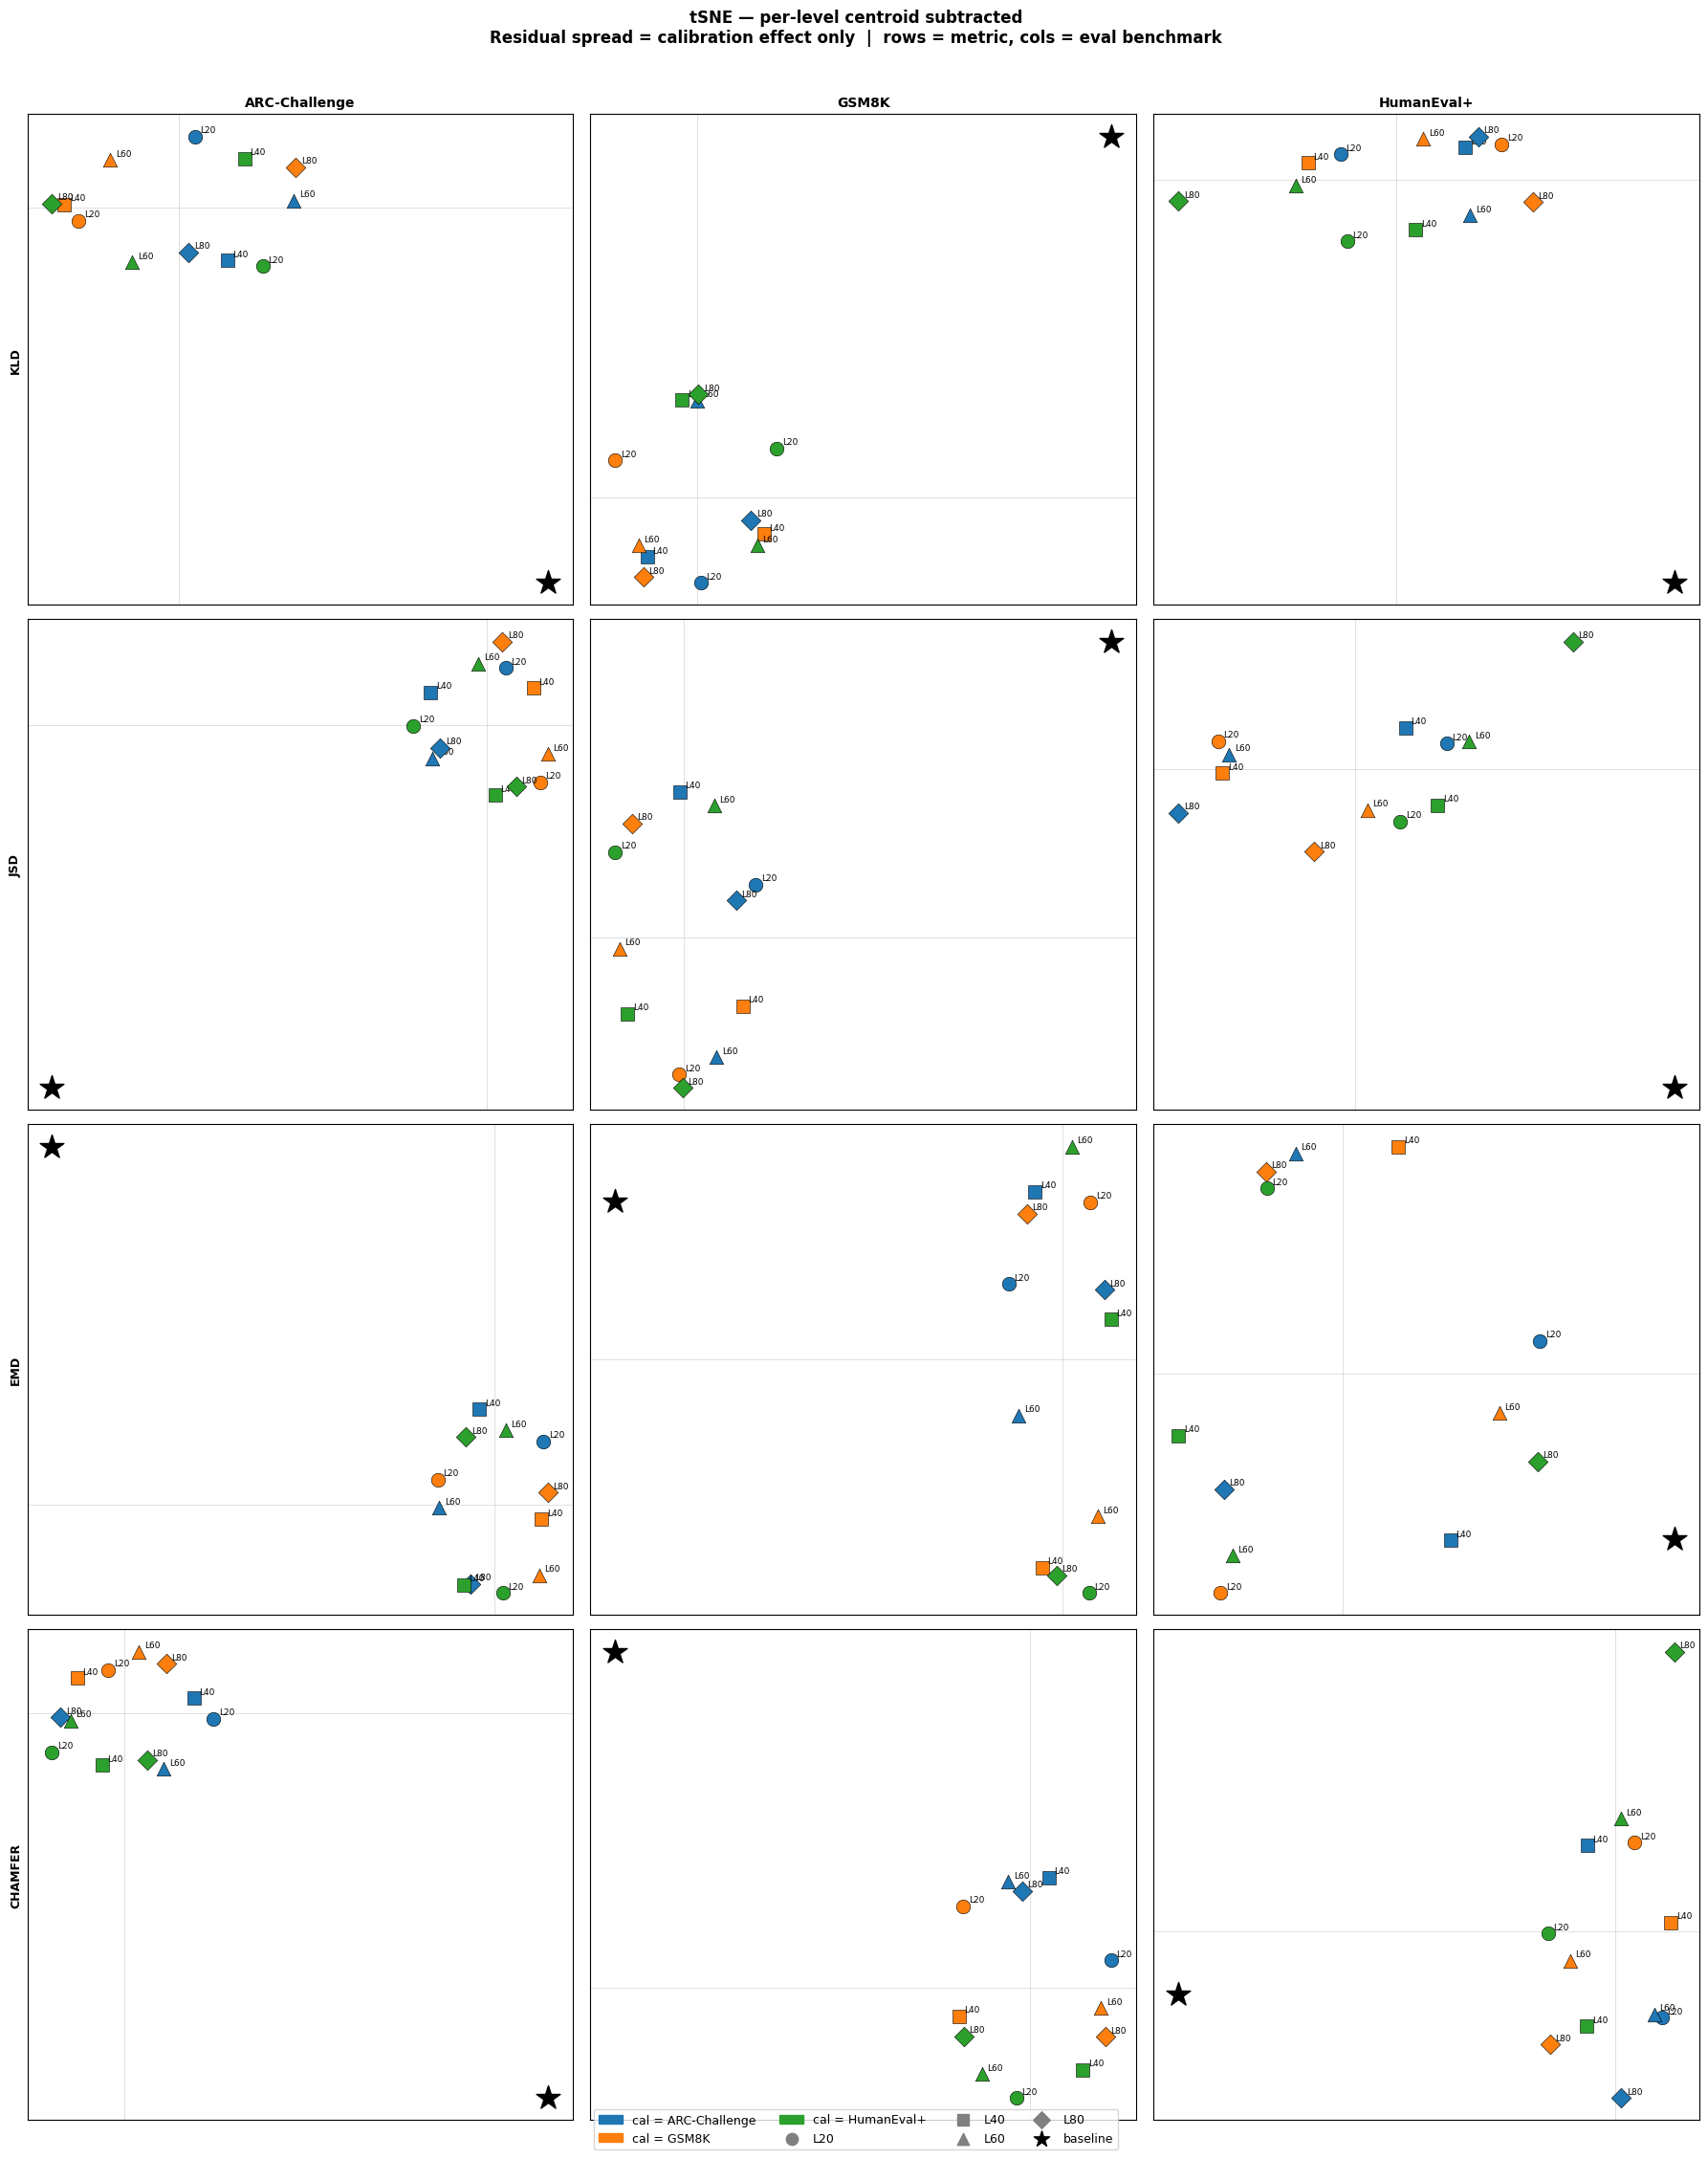

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/umap_centered_all.png


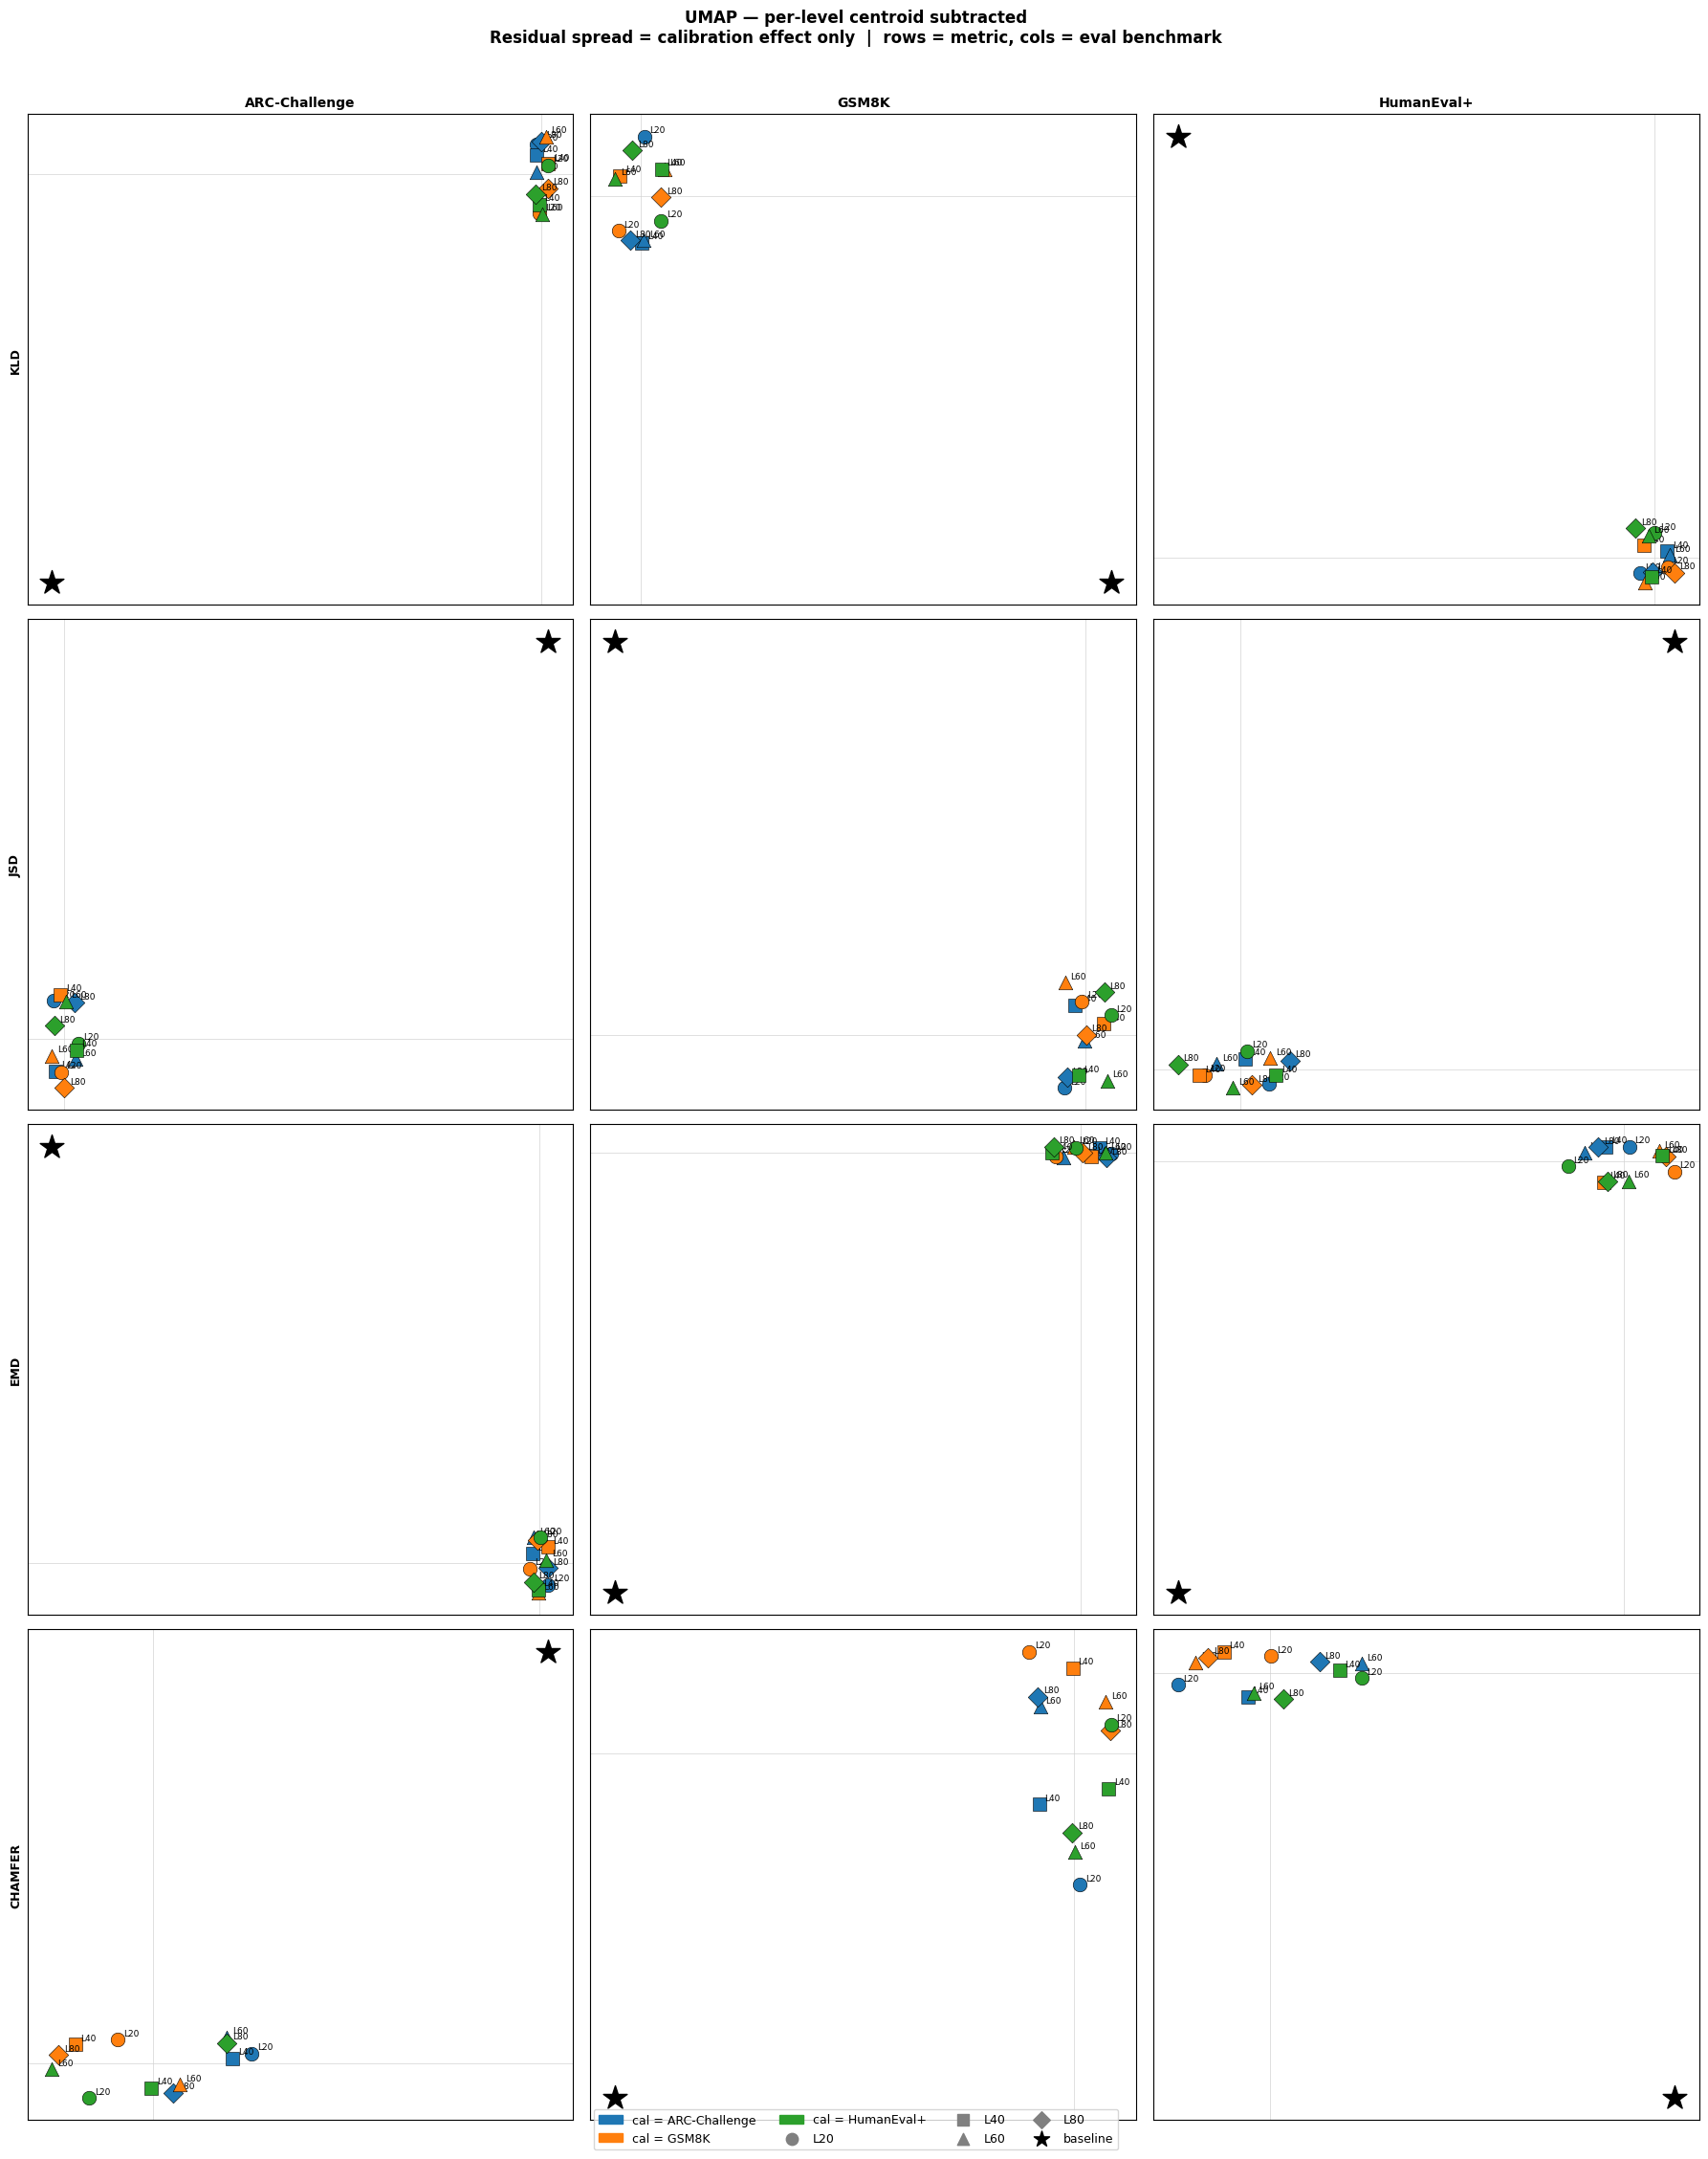

In [16]:
def plot_centered_embeddings(results_dict, algo_name, out_dir):
    """Plot per-level-centroid-subtracted embeddings in a 4×3 grid."""
    # level -> model indices in row_meta (excl. baseline at 0)
    level_idxs = {
        20: [1, 5, 9],
        40: [2, 6, 10],
        60: [3, 7, 11],
        80: [4, 8, 12],
    }

    fig, axes = plt.subplots(4, 3, figsize=(18, 22))
    for row_idx, metric_name in enumerate(METRIC_NAMES):
        for col_idx, eval_bench in enumerate(DATASETS):
            ax       = axes[row_idx, col_idx]
            emb      = results_dict[eval_bench][metric_name]          # (13, 2)
            row_meta = pairwise_matrices[eval_bench][metric_name][1]  # 13 dicts

            # Center each pruning-level cluster around its centroid
            centered = emb.copy()
            for idxs in level_idxs.values():
                centroid = emb[idxs].mean(axis=0)
                centered[idxs] -= centroid

            # Baseline: center relative to mean of all level centroids
            all_centroids = np.stack(
                [emb[idxs].mean(axis=0) for idxs in level_idxs.values()]
            )
            centered[0] -= all_centroids.mean(axis=0)

            # Plot
            ax.axhline(0, color="lightgray", lw=0.5)
            ax.axvline(0, color="lightgray", lw=0.5)
            ax.scatter(
                centered[0, 0], centered[0, 1],
                c="black", marker="*", s=350, zorder=5,
            )
            for i, meta in enumerate(row_meta[1:], start=1):
                level = meta["level"]
                col   = CAL_COLORS[meta["cal"]]
                ax.scatter(
                    centered[i, 0], centered[i, 1],
                    c=col, s=110, zorder=3,
                    edgecolors="k", linewidths=0.4,
                    marker=["o", "s", "^", "D"][[20, 40, 60, 80].index(level)],
                )
                ax.annotate(
                    f"L{level}",
                    (centered[i, 0], centered[i, 1]),
                    xytext=(4, 3), textcoords="offset points", fontsize=6.5,
                )

            if row_idx == 0:
                ax.set_title(BENCHMARK_LABELS[eval_bench], fontsize=10, fontweight="bold")
            if col_idx == 0:
                ax.set_ylabel(metric_name.upper(), fontsize=9, fontweight="bold")
            ax.set_xticks([])
            ax.set_yticks([])

    legend_handles = [
        mpatches.Patch(color=CAL_COLORS[cal], label=f"cal = {BENCHMARK_LABELS[cal]}")
        for cal in DATASETS
    ]
    level_markers = [
        plt.scatter([], [], c="gray", marker=mk, s=80, label=f"L{lv}")
        for lv, mk in zip([20, 40, 60, 80], ["o", "s", "^", "D"])
    ]
    legend_handles.extend(level_markers)
    legend_handles.append(plt.scatter([], [], c="black", marker="*", s=150, label="baseline"))
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=4, fontsize=9,
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.suptitle(
        f"{algo_name} — per-level centroid subtracted\n"
        "Residual spread = calibration effect only  |  rows = metric, cols = eval benchmark",
        fontsize=12, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    out = out_dir / f"{algo_name.lower()}_centered_all.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


CENTERED_DIR = RESULTS_DIR / "cal_signal_figures"
CENTERED_DIR.mkdir(exist_ok=True)
plot_centered_embeddings(tsne_results,  "tSNE", CENTERED_DIR)
plot_centered_embeddings(umap_results,  "UMAP", CENTERED_DIR)


### 3. Normalized calibration divergence

For each (eval benchmark, metric, adjacent level transition L→L+1):

- **cross-cal distance** = mean pairwise distance among the 3 models at level L+1  
- **within-cal step** = mean of the 3 adjacent-level distances (arc L→L+1, gsm8k L→L+1, humaneval L→L+1)  
- **ratio** = cross-cal / within-cal-step  (< 1 means calibration effect is smaller than one pruning step)

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/cal_ratio_arc_challenge.png


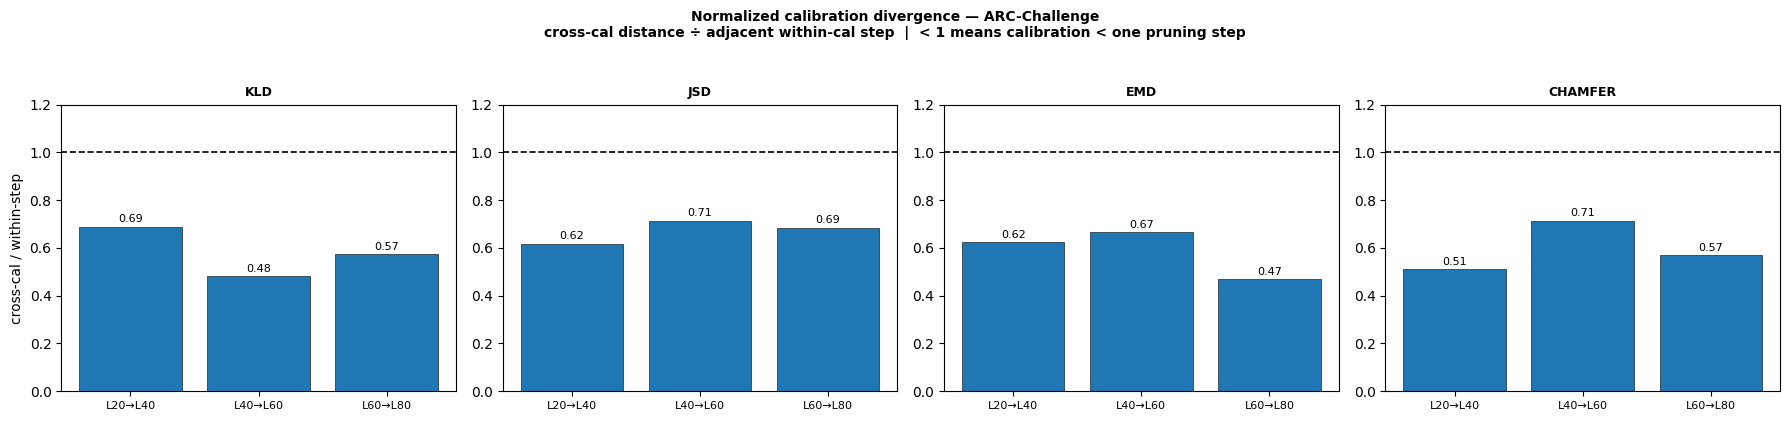

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/cal_ratio_gsm8k.png


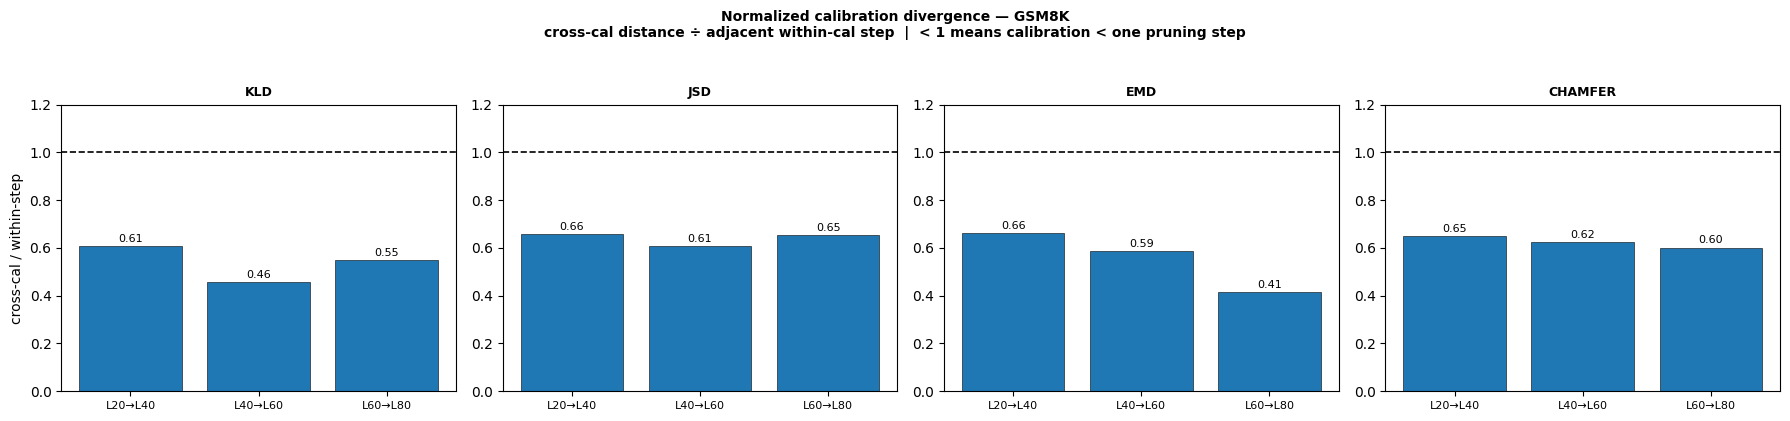

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/cal_ratio_humaneval.png


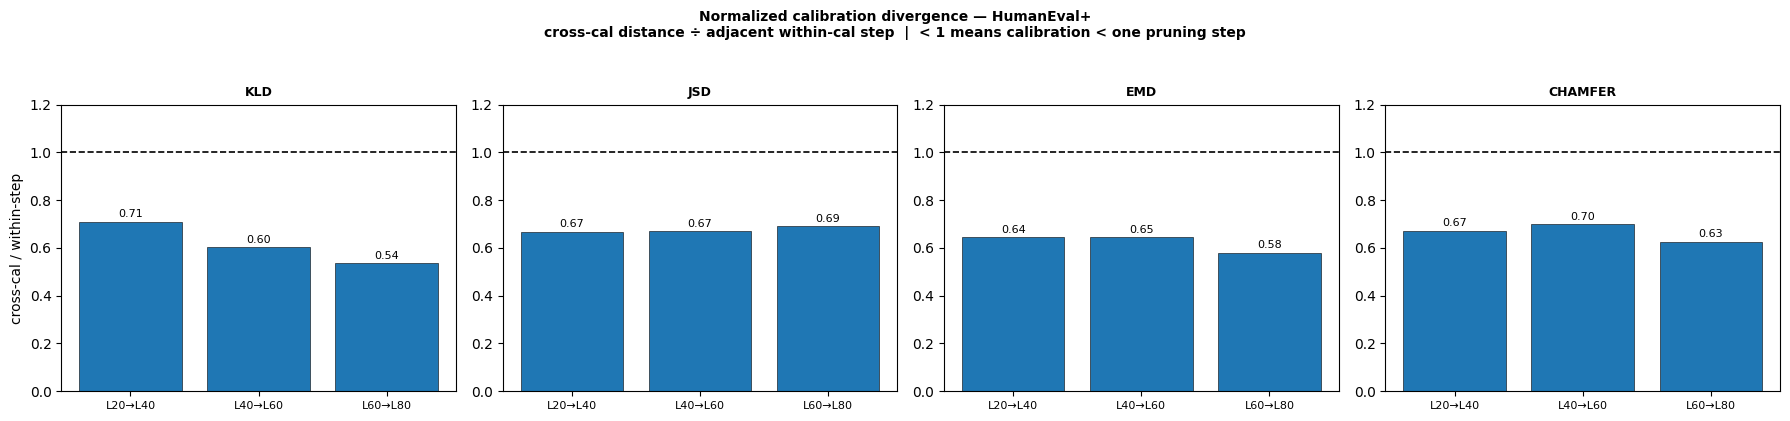

Saved: /var/home/three-kingdoms/work/pruning-metrics/notebooks/experiment/results/cal_signal_figures/cal_ratio_summary.png


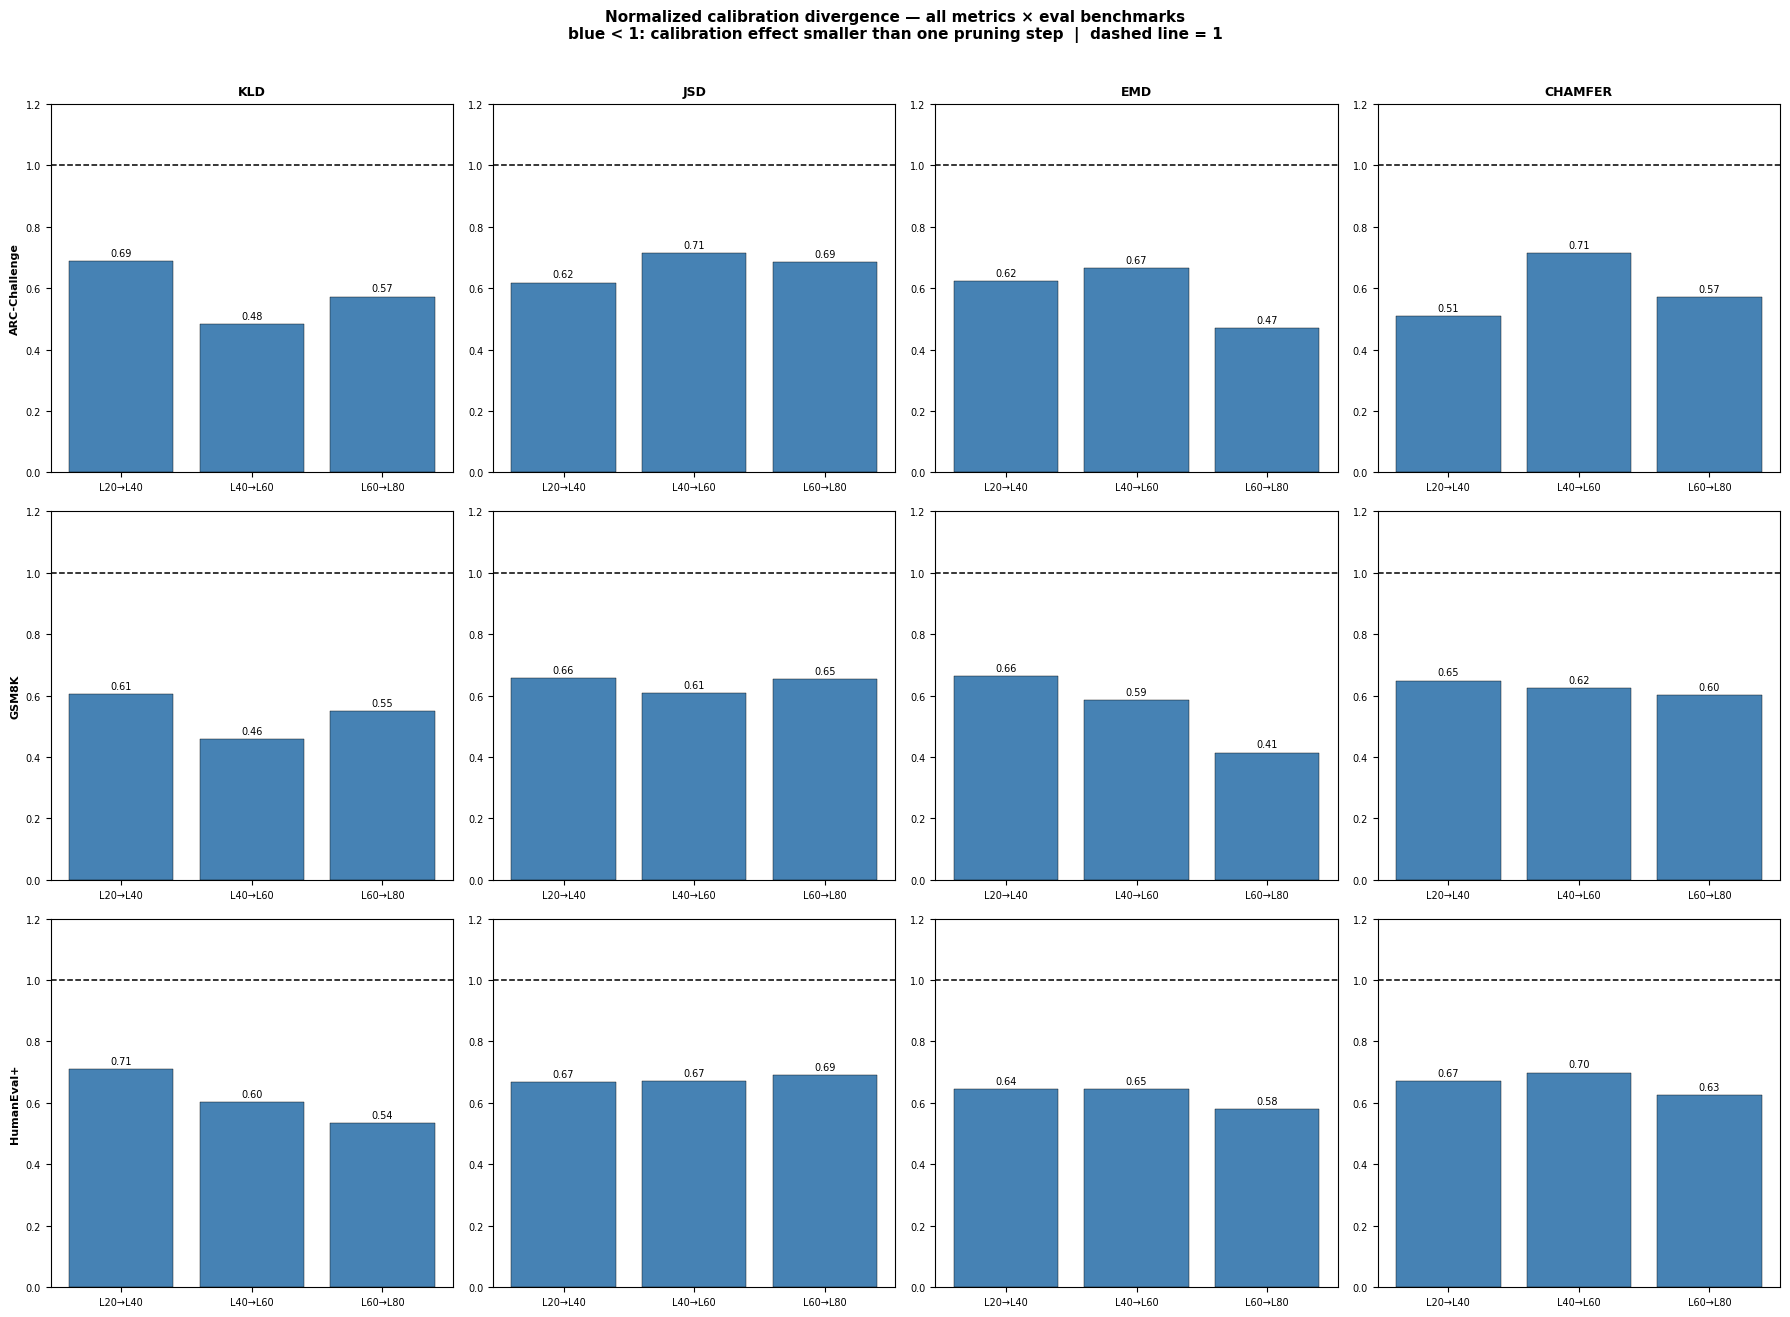

In [17]:
# Compute normalized calibration divergence
# Row ordering: [0]=base, [1-4]=arc L20/40/60/80, [5-8]=gsm8k, [9-12]=humaneval
_level_offsets = {20: 0, 40: 1, 60: 2, 80: 3}
_transitions = [(20, 40), (40, 60), (60, 80)]
_trans_labels = ["L20→L40", "L40→L60", "L60→L80"]

RATIO_FIGURES_DIR = RESULTS_DIR / "cal_signal_figures"
RATIO_FIGURES_DIR.mkdir(exist_ok=True)

for eval_bench in DATASETS:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(
        f"Normalized calibration divergence — {BENCHMARK_LABELS[eval_bench]}\n"
        "cross-cal distance ÷ adjacent within-cal step  |  < 1 means calibration < one pruning step",
        fontsize=10, fontweight="bold", y=1.04,
    )
    for ax, metric_name in zip(axes, METRIC_NAMES):
        D = pairwise_matrices[eval_bench][metric_name][0]
        ratios = []
        for lo, hi in _transitions:
            lo_off, hi_off = _level_offsets[lo], _level_offsets[hi]
            # Indices for hi-level models (arc, gsm8k, humaneval)
            arc_hi = 1 + hi_off
            gsm_hi = 5 + hi_off
            hum_hi = 9 + hi_off
            cross_cal = np.mean([D[arc_hi, gsm_hi], D[arc_hi, hum_hi], D[gsm_hi, hum_hi]])
            # Within-cal: arc lo→hi, gsm8k lo→hi, humaneval lo→hi
            arc_lo = 1 + lo_off
            gsm_lo = 5 + lo_off
            hum_lo = 9 + lo_off
            within_step = np.mean([D[arc_lo, arc_hi], D[gsm_lo, gsm_hi], D[hum_lo, hum_hi]])
            ratios.append(cross_cal / within_step if within_step > 0 else float("nan"))

        colors = ["tab:blue" if r < 1.0 else "tab:red" for r in ratios]
        bars = ax.bar(_trans_labels, ratios, color=colors, edgecolor="k", linewidth=0.4)
        ax.axhline(1.0, color="black", linewidth=1.2, linestyle="--", label="ratio = 1")
        ax.set_ylim(0, max(max(ratios) * 1.15, 1.2))
        ax.set_title(metric_name.upper(), fontsize=9, fontweight="bold")
        ax.set_ylabel("cross-cal / within-step" if metric_name == METRIC_NAMES[0] else "")
        ax.tick_params(axis="x", labelsize=8)
        for bar, ratio in zip(bars, ratios):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{ratio:.2f}", ha="center", va="bottom", fontsize=8,
            )

    fig.tight_layout()
    out = RATIO_FIGURES_DIR / f"cal_ratio_{eval_bench}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

# Combined heatmap summary
fig, axes = plt.subplots(len(DATASETS), 4, figsize=(18, 13))
for row_idx, eval_bench in enumerate(DATASETS):
    for col_idx, metric_name in enumerate(METRIC_NAMES):
        ax = axes[row_idx, col_idx]
        D  = pairwise_matrices[eval_bench][metric_name][0]
        ratio_vals = []
        for lo, hi in _transitions:
            lo_off, hi_off = _level_offsets[lo], _level_offsets[hi]
            arc_hi, gsm_hi, hum_hi = 1+hi_off, 5+hi_off, 9+hi_off
            arc_lo, gsm_lo, hum_lo = 1+lo_off, 5+lo_off, 9+lo_off
            cross   = np.mean([D[arc_hi,gsm_hi], D[arc_hi,hum_hi], D[gsm_hi,hum_hi]])
            within  = np.mean([D[arc_lo,arc_hi], D[gsm_lo,gsm_hi], D[hum_lo,hum_hi]])
            ratio_vals.append(cross / within if within > 0 else float("nan"))
        colors = ["steelblue" if r < 1.0 else "tomato" for r in ratio_vals]
        ax.bar(_trans_labels, ratio_vals, color=colors, edgecolor="k", linewidth=0.3)
        ax.axhline(1.0, color="black", lw=1.1, ls="--")
        ax.set_ylim(0, max(max(r for r in ratio_vals if not np.isnan(r)) * 1.15, 1.2))
        for i, r in enumerate(ratio_vals):
            ax.text(i, r + 0.01, f"{r:.2f}", ha="center", va="bottom", fontsize=7)
        if row_idx == 0:
            ax.set_title(metric_name.upper(), fontsize=9, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(BENCHMARK_LABELS[eval_bench], fontsize=8, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

fig.suptitle(
    "Normalized calibration divergence — all metrics × eval benchmarks\n"
    "blue < 1: calibration effect smaller than one pruning step  |  dashed line = 1",
    fontsize=11, fontweight="bold", y=1.01,
)
fig.tight_layout()
out = RATIO_FIGURES_DIR / "cal_ratio_summary.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()


In [18]:
print("Outputs:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {p.relative_to(NOTEBOOK_DIR)}  ({p.stat().st_size / 1024:.0f} KB)")
print()
print("Cache files:")
for p in sorted(RESULTS_DIR.glob("tsne_model_matrix_*.npy")):
    print(f"  {p.relative_to(NOTEBOOK_DIR)}  ({p.stat().st_size / 1024:.0f} KB)")

Outputs:
  results/tsne_figures/tsne_chamfer.png  (115 KB)
  results/tsne_figures/tsne_emd.png  (116 KB)
  results/tsne_figures/tsne_jsd.png  (115 KB)
  results/tsne_figures/tsne_kld.png  (111 KB)
  results/tsne_figures/tsne_summary_all.png  (197 KB)

Cache files:
  results/tsne_model_matrix_arc_challenge_chamfer.npy  (119 KB)
  results/tsne_model_matrix_arc_challenge_emd.npy  (119 KB)
  results/tsne_model_matrix_arc_challenge_jsd.npy  (119 KB)
  results/tsne_model_matrix_arc_challenge_kld.npy  (119 KB)
  results/tsne_model_matrix_gsm8k_chamfer.npy  (134 KB)
  results/tsne_model_matrix_gsm8k_emd.npy  (134 KB)
  results/tsne_model_matrix_gsm8k_jsd.npy  (134 KB)
  results/tsne_model_matrix_gsm8k_kld.npy  (134 KB)
  results/tsne_model_matrix_humaneval_chamfer.npy  (3 KB)
  results/tsne_model_matrix_humaneval_emd.npy  (3 KB)
  results/tsne_model_matrix_humaneval_jsd.npy  (3 KB)
  results/tsne_model_matrix_humaneval_kld.npy  (3 KB)
